#### Imports / configuration loading

In [ ]:
# Reload imports if needed
# import source
# import importlib
# importlib.reload(source.results_analysis)
# importlib.reload(source.train_predictive_models)
# importlib.reload(source.predictive_models)
# importlib.reload(source.exploration)
# importlib.reload(source.map_loader)

<module 'source.train_predictive_models' from '/home/likescience/SURFIN/predictive_model_latent_space/source/train_predictive_models.py'>

In [13]:

from source import agents, exploration, predictive_models
from source.map_loader import Env
from source.train_predictive_models import process_input, runSGD, one_hot_encode
from source.results_analysis import metrics_predict_map,print_metrics,latent_space_PCA
from pathlib import Path
import source.results_analysis as results_analysis
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch import nn
import json
import os
import textwrap
from tqdm import tqdm
import pandas as pd
import seaborn as sns

map_files = ["20x20_colors.txt", "50x50_colors.txt"] 
map_labels = ["20x20_colors", "50x50_colors"] 
dims = [[20,20],[50,50]]
map_types = ["color","color"]
config_files = ["egocentric_empty_7x7view_rnn.json","egocentric_empty_7x7view_rnn_separate_action.json"]
seeds = [77243, 798315, 965307, 159144, 101125]
configs = []

for config in config_files:
    with open(f"configs/variances_egocentic_models/{config}", 'r') as file: 
       configs.append(json.load(file))

####  Data generation

In [3]:
loaded_data = [{k3: None for k3 in seeds} for i in range(len(map_files))] 
observation_spaces = {"egocentric": exploration.exploration_egocentric,"allocentric":exploration.exploration_allocentric}

config = configs[0]
observation_space = config["observation_space"]

data_keys = ['img_train', 'pos_train', 'dir_train', 'img_test', 'pos_test', 'dir_test']
for c in range(len(map_files)):
    with open(f"maps/{map_files[c]}", 'r') as file:
        map = [[int(x) for x in line.strip().split(" ")] for line in file ]
    if (map_types[c]=="color"):
        with open(f"maps/colors/{map_files[c]}", 'r') as file:
            color_map = [[int(x) for x in line.strip().split(" ")] for line in file ]
    else:
        color_map = None
    env = Env(map,dims[c],tuple(config['start_pos']),seed=config['env_seed'],render_mode="rgb_array",agent_view_size=config['egocentric_view_size'])
    env.reset(seed=env.env_seed)
    for seed in seeds:
        if observation_space == "egocentric":
            agent_type = ["random", [0.3333, 0.3333, 0.3334],seed]
        elif observation_space == "allocentric":
            agent_type = ["random", [0.25, 0.25, 0.25, 0.25], seed]

        outfolder = f"exploration_data/variances_egocentic_models/{map_labels[c]}"
        outdir = f"{outfolder}/{seed}_exploration_data.npz"
        Path(outfolder).mkdir(parents=True, exist_ok=True)
        print(f"Setting:{c}, {observation_space}, {seed}")
        try:
            with np.load(outdir) as data:
                loaded_data[c][seed] = [data[k] for k in data_keys]
                print ("Successfully loaded data!")
        except (FileNotFoundError, Exception):
            config['agent_type'][2] = seed
            env = Env(map,dims[c],tuple(config['start_pos']),seed=seed,render_mode="rgb_array",agent_view_size=config['egocentric_view_size'],colors=color_map)
            env.reset(seed=env.env_seed)
            loaded_data[c][seed] = observation_spaces[observation_space](
            env,
            agent_type=agent_type,
            n_steps_train=config['number_steps_train'],
            n_steps_test=config['number_steps_test'],
            n_restart_train=config['num_random_position_restarts_train'],
            n_restart_test=config['num_random_position_restarts_test'],
            rgb_rep=True)
            exploration_data = loaded_data[c][seed]
            np.savez_compressed(outdir, **dict(zip(data_keys, exploration_data)))
            print ("Exploration complete!")


Setting:0, egocentric, 77243


100%|██████████| 1000/1000 [00:00<00:00, 2234.13it/s]


Exploration complete!
Setting:0, egocentric, 798315


100%|██████████| 1000/1000 [00:00<00:00, 1959.41it/s]


Exploration complete!
Setting:0, egocentric, 965307


...

Exploration complete!
Setting:1, egocentric, 159144


100%|██████████| 1000/1000 [00:00<00:00, 2374.01it/s]


Exploration complete!
Setting:1, egocentric, 101125


100%|██████████| 1000/1000 [00:00<00:00, 1890.72it/s]


Exploration complete!


#### Training predictive models

  0%|          | 0/5 [00:00<?, ?it/s]

 20%|██        | 1/5 [00:01<00:05,  1.40s/it]

Loaded model!


 40%|████      | 2/5 [00:02<00:04,  1.33s/it]

Loaded model!


...

Loaded model!


100%|██████████| 5/5 [00:06<00:00,  1.37s/it]


Loaded model!


  0%|          | 0/5 [00:00<?, ?it/s]

Epoch 	 Loss train 	 Loss test
1/60	 2638.8806		 2612.2988
2/60	 2513.8469		 2473.0632
3/60	 2478.0535		 2437.1294
4/60	 2422.8162		 2380.8159
5/60	 2375.3694		 2335.0525
6/60	 2348.2136		 2315.6855
7/60	 2332.1650		 2303.5071
8/60	 2319.7449		 2297.3020
9/60	 2310.5950		 2289.4336
10/60	 2296.6145		 2280.2493
11/60	 2293.9277		 2279.1660
12/60	 2282.2285		 2272.6545
13/60	 2261.2751		 2252.2612
14/60	 2248.3691		 2245.3691
15/60	 2240.1101		 2234.0405
16/60	 2218.8291		 2223.8972
17/60	 2202.2776		 2213.0186
18/60	 2171.6545		 2173.3826
19/60	 2117.1975		 2122.7493
20/60	 2031.9135		 2040.5021
21/60	 1914.7097		 1918.8678
22/60	 1795.0099		 1786.7336
23/60	 1686.7631		 1684.3452
24/60	 1588.0225		 1594.5157
25/60	 1506.9550		 1517.2037
26/60	 1451.6534		 1477.8883
27/60	 1363.0170		 1394.3110
28/60	 1339.2507		 1364.9940
29/60	 1312.3572		 1335.1611
30/60	 1208.1377		 1242.8940
31/60	 1167.4338		 1205.6027
32/60	 1140.8684		 1177.1259
33/60	 1113.3744		 1150.1287
34/60	 1090.2380		 11

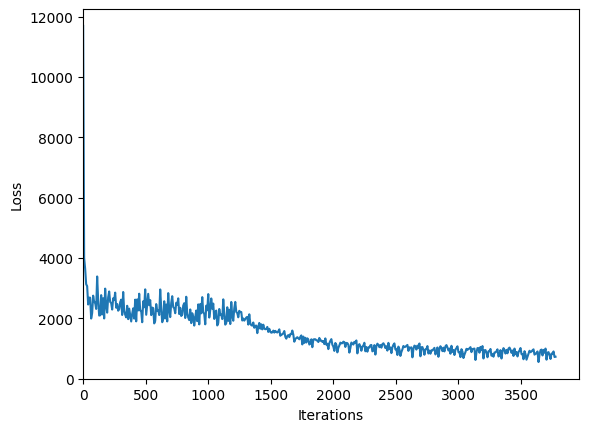

 20%|██        | 1/5 [03:02<12:10, 182.54s/it]

Epoch 	 Loss train 	 Loss test
1/60	 2584.3008		 2596.6067
2/60	 2568.3567		 2571.3608
3/60	 2472.5049		 2475.5103
4/60	 2432.2700		 2436.6182
5/60	 2410.3894		 2415.9871
6/60	 2390.1553		 2398.2300
7/60	 2357.2673		 2370.3840
8/60	 2346.1350		 2362.2710
9/60	 2346.1899		 2362.5242
10/60	 2338.9304		 2358.1204
11/60	 2325.0771		 2350.5920
12/60	 2282.7686		 2315.5505
13/60	 2275.4749		 2313.0327
14/60	 2263.1982		 2303.3967
15/60	 2246.5647		 2291.1309
16/60	 2234.8655		 2281.1794
17/60	 2203.8599		 2256.4863
18/60	 2194.9768		 2247.7734
19/60	 2175.6770		 2235.4053
20/60	 2152.4956		 2210.4304
21/60	 2101.2974		 2167.0681
22/60	 2036.8319		 2093.8630
23/60	 1949.3955		 1990.8838
24/60	 1848.3806		 1875.3833
25/60	 1753.1588		 1762.9451
26/60	 1648.8052		 1637.9286
27/60	 1569.3167		 1551.7477
28/60	 1464.9730		 1452.3788
29/60	 1419.0470		 1400.7296
30/60	 1334.5690		 1325.6461
31/60	 1278.1616		 1278.9897
32/60	 1228.0156		 1232.4380
33/60	 1192.4934		 1204.4369
34/60	 1158.6127		 11

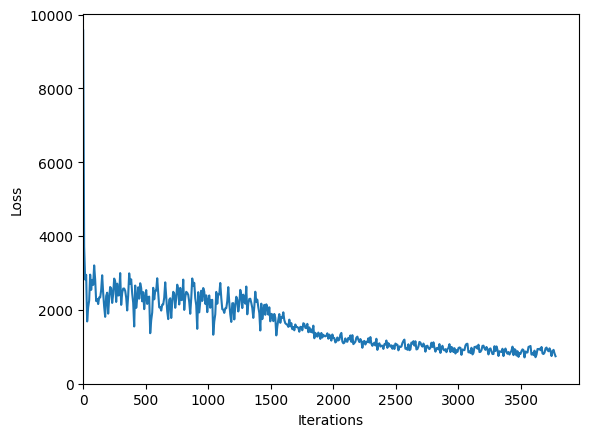

 40%|████      | 2/5 [06:11<09:18, 186.18s/it]

Epoch 	 Loss train 	 Loss test
1/60	 2567.0332		 2425.1240
2/60	 2492.0288		 2370.7300
3/60	 2448.1311		 2340.5686
4/60	 2416.8787		 2318.2983
5/60	 2357.8464		 2265.6077
6/60	 2332.5427		 2242.8723
7/60	 2315.7715		 2236.4668
8/60	 2301.5764		 2229.8054
9/60	 2289.1616		 2225.2642
10/60	 2274.8516		 2216.6194
11/60	 2259.8325		 2207.1792
12/60	 2246.6497		 2200.7351
13/60	 2233.8467		 2191.9502
14/60	 2223.5435		 2183.2305
15/60	 2208.3181		 2175.3379
16/60	 2203.8438		 2175.1372
17/60	 2193.4570		 2170.4597
18/60	 2180.4519		 2160.7432
19/60	 2144.6631		 2129.6018
20/60	 2105.5022		 2103.2490
21/60	 2055.0120		 2047.5862
22/60	 2010.5773		 2014.4213
23/60	 1939.0883		 1958.8596
24/60	 1846.7902		 1888.8596
25/60	 1784.1487		 1826.0946
26/60	 1701.5988		 1753.5204
27/60	 1591.8817		 1659.5212
28/60	 1503.9952		 1581.4109
29/60	 1415.6466		 1506.9480
30/60	 1364.3285		 1458.7083
31/60	 1335.1077		 1430.4149
32/60	 1270.7727		 1361.2344
33/60	 1251.0154		 1342.7477
34/60	 1204.4189		 12

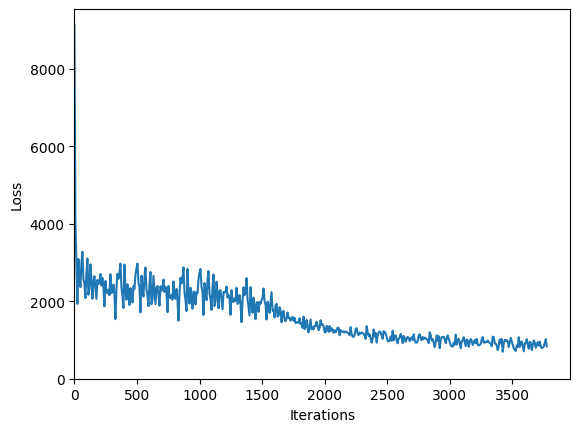

 60%|██████    | 3/5 [09:09<06:04, 182.48s/it]

Epoch 	 Loss train 	 Loss test
1/60	 2531.2002		 2796.8386
2/60	 2461.8882		 2714.8997
3/60	 2392.5525		 2631.9128
4/60	 2363.0217		 2594.2058
5/60	 2331.0469		 2561.2097
6/60	 2340.4573		 2571.4622
7/60	 2305.0564		 2536.5256
8/60	 2290.5112		 2521.4465
9/60	 2285.2783		 2514.2927
10/60	 2279.1467		 2509.0071
11/60	 2268.8240		 2497.7781
12/60	 2262.9121		 2491.9438
13/60	 2247.7510		 2480.3079
14/60	 2249.0635		 2484.6733
15/60	 2241.7798		 2477.8513
16/60	 2240.3892		 2478.4607
17/60	 2221.7373		 2469.1069
18/60	 2219.6499		 2473.0447
19/60	 2203.6763		 2450.9482
20/60	 2170.5408		 2416.7935
21/60	 2119.9653		 2372.2153
22/60	 2111.6699		 2366.9219
23/60	 2058.4651		 2296.1501
24/60	 2004.3839		 2234.3855
25/60	 1960.2651		 2178.7517
26/60	 1885.3956		 2092.7124
27/60	 1792.6892		 1968.0417
28/60	 1697.6927		 1831.3719
29/60	 1560.9133		 1652.4772
30/60	 1472.4812		 1539.0283
31/60	 1404.5994		 1436.9680
32/60	 1337.3690		 1354.0073
33/60	 1294.2305		 1301.9476
34/60	 1254.1564		 12

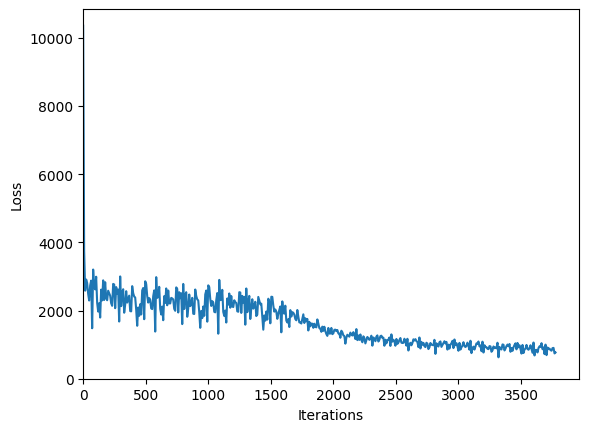

 80%|████████  | 4/5 [12:13<03:03, 183.27s/it]

Epoch 	 Loss train 	 Loss test
1/60	 2567.8848		 2701.6489
2/60	 2451.9463		 2577.0481
3/60	 2393.7966		 2502.3843
4/60	 2367.8267		 2478.3618
5/60	 2311.2490		 2429.1541
6/60	 2302.5657		 2422.2029
7/60	 2296.8848		 2421.3057
8/60	 2292.6404		 2423.5989
9/60	 2277.7493		 2409.5161
10/60	 2267.4023		 2404.9006
11/60	 2252.3513		 2392.8547
12/60	 2244.9246		 2388.9717
13/60	 2224.5432		 2372.6060
14/60	 2214.9375		 2365.1294
15/60	 2214.4966		 2362.8147
16/60	 2201.7002		 2351.0737
17/60	 2170.5476		 2322.0664
18/60	 2155.9241		 2307.7124
19/60	 2152.5339		 2304.4653
20/60	 2134.3623		 2288.5098
21/60	 2137.2888		 2288.3284
22/60	 2135.4255		 2272.8589
23/60	 2090.9067		 2223.2517
24/60	 2018.0144		 2159.6831
25/60	 1962.5117		 2117.0796
26/60	 1909.2180		 2031.2993
27/60	 1810.4183		 1934.3262
28/60	 1729.7740		 1836.0948
29/60	 1601.5382		 1690.1584
30/60	 1509.0172		 1577.7773
31/60	 1456.2122		 1512.7306
32/60	 1397.3789		 1433.3408
33/60	 1356.2974		 1386.1279
34/60	 1304.4744		 13

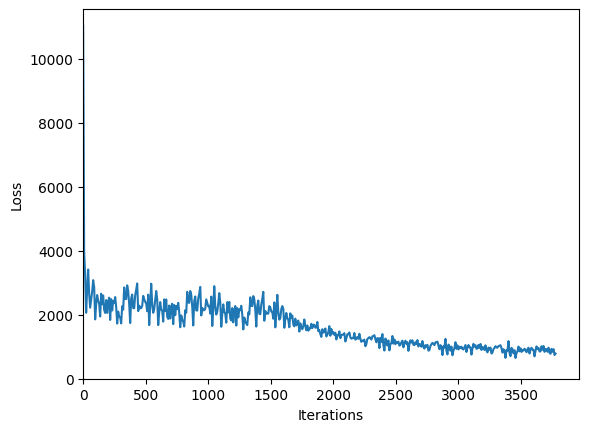

  0%|          | 0/5 [00:00<?, ?it/s]

Epoch 	 Loss train 	 Loss test
1/60	 1965.8136		 1980.5255
2/60	 1933.7596		 1954.2616
3/60	 1861.0999		 1883.7445
4/60	 1835.0118		 1859.2169
5/60	 1837.6976		 1862.7860
6/60	 1837.0310		 1866.8281
7/60	 1821.2888		 1854.0802
8/60	 1820.4355		 1853.6005
9/60	 1794.1862		 1832.7844
10/60	 1789.5564		 1831.7448
11/60	 1794.2239		 1837.9529
12/60	 1776.7107		 1826.1306
13/60	 1773.6558		 1827.3278
14/60	 1767.1737		 1820.8044
15/60	 1751.7697		 1811.4054
16/60	 1743.6620		 1803.3328
17/60	 1745.1799		 1807.8501
18/60	 1756.9117		 1818.7371
19/60	 1736.7355		 1805.2516
20/60	 1711.0510		 1783.8528
21/60	 1722.8185		 1794.9607
22/60	 1728.1130		 1805.0387
23/60	 1729.0898		 1806.5465
24/60	 1704.8323		 1787.4180
25/60	 1699.6310		 1782.6704
26/60	 1687.5143		 1770.8737
27/60	 1672.5713		 1758.3074
28/60	 1675.4048		 1768.1411
29/60	 1660.0999		 1741.8413
30/60	 1675.0742		 1756.7659
31/60	 1672.9087		 1752.2220
32/60	 1687.3455		 1759.2091
33/60	 1646.9192		 1727.2363
34/60	 1608.6532		 16

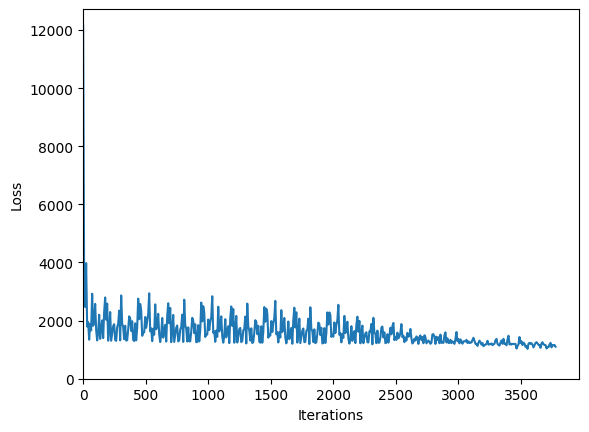

 20%|██        | 1/5 [03:07<12:31, 187.90s/it]

Epoch 	 Loss train 	 Loss test
1/60	 2081.4463		 1675.7324
2/60	 2045.1655		 1675.7152
3/60	 1965.7065		 1619.5430
4/60	 1941.2285		 1603.9937
5/60	 1917.6471		 1590.9148
6/60	 1904.8682		 1584.2167
7/60	 1893.1930		 1577.2963
8/60	 1882.6609		 1568.3542
9/60	 1868.4590		 1561.1250
10/60	 1858.3652		 1554.8514
11/60	 1848.6862		 1549.6693
12/60	 1831.2322		 1534.0106
13/60	 1817.3729		 1519.4962
14/60	 1809.4637		 1513.9592
15/60	 1803.1766		 1512.0320
16/60	 1798.5886		 1509.3372
17/60	 1791.3708		 1506.5859
18/60	 1789.9540		 1513.2174
19/60	 1776.3280		 1505.9633
20/60	 1772.1819		 1502.8790
21/60	 1774.8022		 1509.1646
22/60	 1770.9252		 1512.5607
23/60	 1756.8652		 1507.8004
24/60	 1741.3785		 1497.8787
25/60	 1730.4575		 1487.9744
26/60	 1731.2061		 1484.3859
27/60	 1726.3073		 1487.5652
28/60	 1711.8220		 1482.8956
29/60	 1710.3978		 1490.8282
30/60	 1694.7579		 1484.8647
31/60	 1662.9088		 1479.0409
32/60	 1637.4528		 1461.8440
33/60	 1628.8362		 1462.8708
34/60	 1599.9557		 14

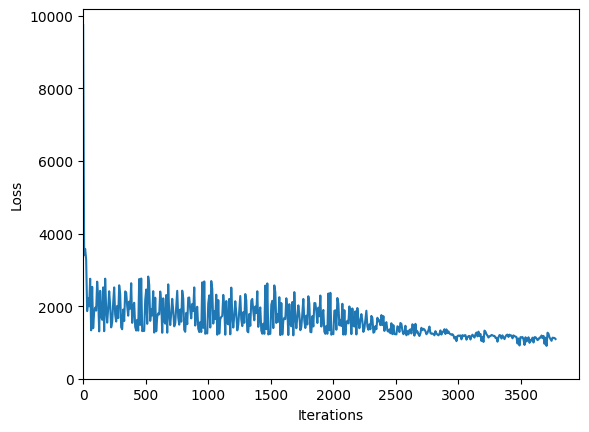

 40%|████      | 2/5 [06:03<09:02, 180.79s/it]

Epoch 	 Loss train 	 Loss test
1/60	 1943.4103		 1415.3641
2/60	 1838.3597		 1336.2889
3/60	 1800.9813		 1324.8649
4/60	 1781.6548		 1317.9574
5/60	 1770.2286		 1311.9436
6/60	 1755.3334		 1303.7228
7/60	 1752.6106		 1307.0389
8/60	 1740.7334		 1299.7975
9/60	 1729.0742		 1289.7000
10/60	 1713.7830		 1278.9863
11/60	 1698.3271		 1269.0668
12/60	 1678.3969		 1250.8761
13/60	 1676.8041		 1252.3464
14/60	 1676.2367		 1255.2939
15/60	 1673.5626		 1256.6060
16/60	 1674.3000		 1264.7373
17/60	 1647.4153		 1231.0526
18/60	 1645.0874		 1226.0924
19/60	 1633.6189		 1222.3335
20/60	 1636.7264		 1221.9613
21/60	 1632.9735		 1227.1936
22/60	 1637.3267		 1239.1714
23/60	 1627.2068		 1230.2948
24/60	 1626.9487		 1232.1528
25/60	 1623.2904		 1231.1771
26/60	 1626.1531		 1231.1478
27/60	 1644.4224		 1231.0831
28/60	 1619.5642		 1221.0626
29/60	 1610.5991		 1223.2439
30/60	 1621.2462		 1230.1005
31/60	 1606.6991		 1214.7074
32/60	 1599.3546		 1219.6486
33/60	 1600.8499		 1221.8162
34/60	 1577.6945		 12

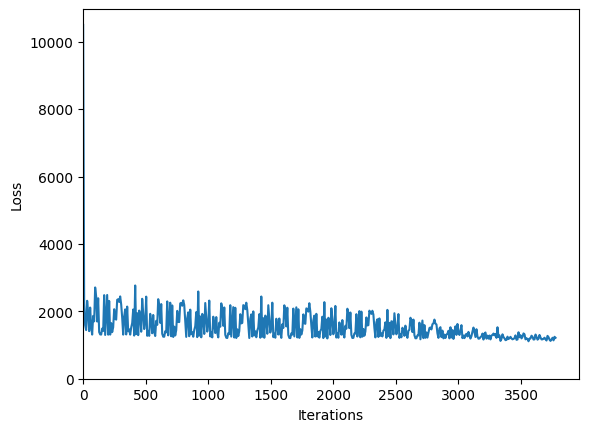

 60%|██████    | 3/5 [08:49<05:47, 173.97s/it]

Epoch 	 Loss train 	 Loss test
1/60	 1846.0173		 2536.2485
2/60	 1793.2086		 2448.0823
3/60	 1775.2833		 2408.8845
4/60	 1757.0754		 2364.2598
5/60	 1745.2429		 2350.5305
6/60	 1726.6942		 2327.0093
7/60	 1708.6107		 2301.4404
8/60	 1698.9139		 2290.5620
9/60	 1683.8705		 2282.9016
10/60	 1678.7458		 2285.4858
11/60	 1678.1847		 2285.6521
12/60	 1662.3766		 2270.6614
13/60	 1648.9161		 2262.6660
14/60	 1647.1091		 2264.3425
15/60	 1660.8644		 2281.4067
16/60	 1636.7083		 2267.9165
17/60	 1630.2889		 2268.4219
18/60	 1628.3712		 2268.8711
19/60	 1635.8843		 2272.8787
20/60	 1613.1100		 2267.0520
21/60	 1611.9233		 2266.5320
22/60	 1597.9716		 2259.9829
23/60	 1608.6243		 2279.8362
24/60	 1609.1859		 2288.4475
25/60	 1602.3228		 2273.7002
26/60	 1608.6941		 2288.5071
27/60	 1590.1823		 2298.0327
28/60	 1591.2419		 2293.6433
29/60	 1607.6125		 2311.9714
30/60	 1601.4708		 2294.6626
31/60	 1576.8278		 2272.6997
32/60	 1598.1556		 2310.2700
33/60	 1571.2456		 2268.0251
34/60	 1580.1814		 22

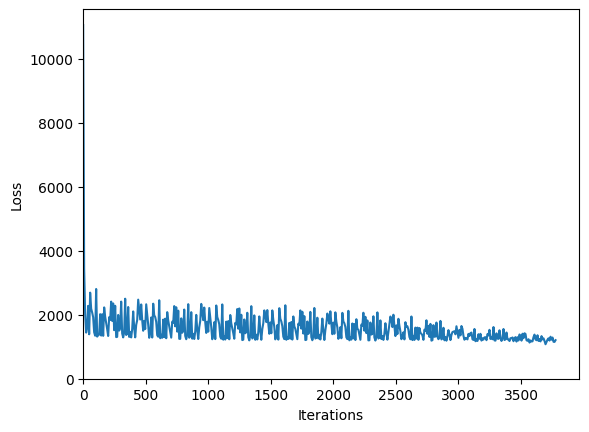

 80%|████████  | 4/5 [11:33<02:50, 170.10s/it]

Epoch 	 Loss train 	 Loss test
1/60	 1894.7086		 1538.9011
2/60	 1809.0421		 1475.0295
3/60	 1786.3522		 1462.9333
4/60	 1767.4374		 1454.4175
5/60	 1750.6217		 1449.5686
6/60	 1734.6283		 1438.9562
7/60	 1717.5366		 1423.4720
8/60	 1701.7035		 1410.4390
9/60	 1690.4159		 1404.0278
10/60	 1683.1617		 1400.6135
11/60	 1671.4836		 1391.0592
12/60	 1664.2057		 1384.3245
13/60	 1654.6244		 1379.8542
14/60	 1644.2494		 1373.5032
15/60	 1638.4221		 1370.3335
16/60	 1635.8894		 1371.7181
17/60	 1623.1694		 1362.9215
18/60	 1628.5409		 1372.0439
19/60	 1649.9507		 1390.9242
20/60	 1638.1272		 1387.7328
21/60	 1630.2277		 1375.3188
22/60	 1618.9382		 1368.9784
23/60	 1600.9147		 1356.0680
24/60	 1607.4337		 1373.9983
25/60	 1605.2467		 1376.7802
26/60	 1602.2396		 1376.5264
27/60	 1597.4738		 1375.5231
28/60	 1580.3242		 1364.3752
29/60	 1577.2062		 1373.0791
30/60	 1561.2603		 1363.7908
31/60	 1552.0004		 1353.7892
32/60	 1552.4707		 1368.6516
33/60	 1550.9128		 1374.1683
34/60	 1544.0352		 13

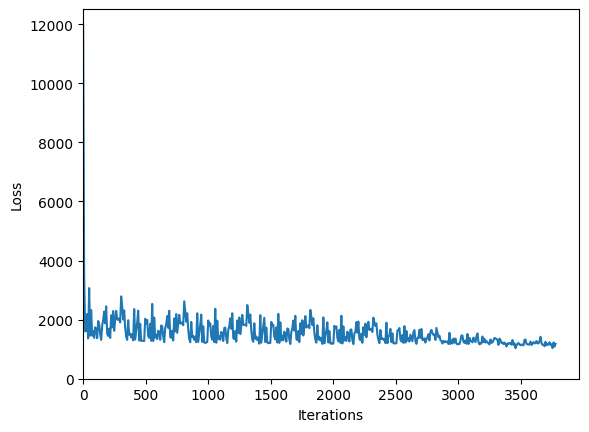

100%|██████████| 5/5 [18:35<00:00, 223.13s/it]


In [17]:
config_names = [config["config_name"] for config in configs]
loaded_models = {k2: [{k3: None for k3 in seeds} for i in range(len(map_files))] for k2 in config_names}
processed_inputs = {k2: [{k3: None for k3 in seeds} for i in range(len(map_files))] for k2 in config_names}

for config in configs:
    for c in range(len(map_files)):
        for seed in tqdm(seeds):
            image_list_train, pos_list_train, dir_list_train, image_list_test, pos_list_test, dir_list_test = loaded_data[c][seed]

            X_train,X_test= image_list_train,image_list_test 

            target_train = X_train[1:]
            input_train = X_train[:-1]
            target_test = X_test[1:]
            input_test = X_test[:-1]

            target_train = torch.tensor(target_train, dtype=torch.int64)
            input_train = torch.tensor(input_train, dtype=torch.int64)
            target_test = torch.tensor(target_test, dtype=torch.int64)
            input_test = torch.tensor(input_test, dtype=torch.int64)
            
            scaling_factor=1

            if config["observation_space"]=="allocentric":
                img_width, img_height = config["map_dims"][0], config["map_dims"][1]
            else:
                img_width, img_height = config["egocentric_view_size"], config["egocentric_view_size"]

            input_train_processed = torch.stack([process_input(x, 'in',img_width,img_height,scaling_factor,3) for x in input_train])
            target_train_processed = torch.stack([process_input(x, 'out',img_width,img_height,scaling_factor,3) for x in target_train])
            input_test_processed = torch.stack([process_input(x, 'in',img_width,img_height,scaling_factor,3) for x in input_test])
            target_test_processed = torch.stack([process_input(x, 'out',img_width,img_height,scaling_factor,3) for x in target_test])


            processed_inputs[config["config_name"]][c][seed] = [input_train_processed, target_train_processed]

            latent_size=config["latent_size"]
            hidden_fac=15
            img_channels=3
            input_size=input_train_processed.size(1)
            output_size = target_train_processed.size(1)
            torch.manual_seed(config["model_seed"])
            torch.use_deterministic_algorithms(True)
            train_flag = True
            device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
            if config['model_type'] == "autoencoder_no_rnn":
                model = predictive_models.AutoencoderWithoutRNN(input_size, output_size, hidden_fac, latent_size,device)
            elif config["model_type"]=="autoencoder_rnn":
                model = predictive_models.AutoencoderWithRNN(input_size, output_size, hidden_fac, latent_size,device)
            elif config["model_type"]=="autoencoder_rnn_separate_action":
                model = predictive_models.AutoencoderRNNSeparateAction(img_width*img_height*img_channels,input_size-img_width*img_height*img_channels, output_size, hidden_fac, latent_size,device)
            else:
                model = predictive_models.AutoencoderInputs(img_width*img_height,device)
                train_flag = False
            n_epochs, batch_size = config['number_epochs'], config['batch_size']
            MODEL_PATH = f"trained_models/variances_egocentric_models/{config['predictive_model_path']}_{c}_{seed}.pt"
            if (config["load_trained_model_if_existent"] and os.path.exists(MODEL_PATH)) and config["model_type"]!="inputs":
                try:
                    model.load_state_dict(torch.load(MODEL_PATH, map_location=device, weights_only=True))
                    print("Loaded model!")
                    # with open(f"outputs/variances_egocentric_models/model_evaluation/{config['config_name']}_{c}_{seed}.json", "r") as f:
                    #     metrics = json.load(f)
                    train_flag = False
                except (RuntimeError, KeyError, EOFError) as e:
                    print("Failed to load model - will proceed to training!")
            if train_flag:
                tracked_losses_train, tracked_losses_test = runSGD(model, input_train_processed, target_train_processed, input_test_processed, target_test_processed, device=device, n_epochs=n_epochs, batch_size=batch_size,seed=config["model_seed"],notrain=(not config["train"]))
                if (config['save_trained_model']):
                    torch.save(model.state_dict(), MODEL_PATH)

            loaded_models[config["config_name"]][c][seed] = model 

#### PCA on latent space 

In [ ]:
top_components = {k2: [{k3: [] for k3 in seeds} for i in range(len(map_files))] for k2 in config_names}

for config in configs:
    for c in tqdm(range(len(map_files))):
        for seed in tqdm(seeds):
            OUT_DIR = f"outputs/variances_egocentic_models/latent_space_PCA/{map_labels[c]}_{config['model_type']}/{seed}"
            input_train_processed = processed_inputs[config["config_name"]][c][seed][0]
            image_list_train, pos_list_train, dir_list_train, image_list_test, pos_list_test, dir_list_test = loaded_data[c][seed]
            model = loaded_models[config["config_name"]][c][seed]
            # latent_space_before, latent_space_after = model.get_latent(input_train_processed)
            all_latent_spaces = [(model.get_latent(i.view(1,-1))) for i in input_train_processed]
            latent_space_before = torch.stack([i[0] for i in all_latent_spaces]).squeeze(1)
            latent_space_after_list = [i[1] for i in all_latent_spaces]
            if all(val is not None for val in latent_space_after_list):
                latent_space_after = torch.stack(latent_space_after_list).squeeze(1)
            else:
                latent_space_after = None

            # if (config["model_type"] == "autoencoder_rnn"):
            #     latent_spaces = [[latent_space_before, "before_RNN"],[latent_space_after, "after_RNN"]]
            # else:
            latent_spaces = [[latent_space_before, ""]]
            print(config["config_name"], map_labels[c],seed)
            top_components[config["config_name"]][c][seed] = latent_space_PCA(latent_spaces,config,pos_list_train[:-1],dir_list_train[:-1],img_width,img_height,outdir=OUT_DIR)



##### Violin plots

In [29]:
data_directories = [('outputs/variances_egocentic_models/latent_space_PCA',''),('outputs/variances_egocentic_input_spaces/latent_space_PCA','_input_space')]
labels_to_use= ["20x20_colors","50x50_colors","20x20_colors_autoencoder_rnn","50x50_colors_autoencoder_rnn","20x20_colors_autoencoder_rnn_separate_action","50x50_colors_autoencoder_rnn_separate_action"]

OUT_DIR_VAR = f"outputs/variances_egocentic_models/latent_space_PCA/"
Path(OUT_DIR_VAR).mkdir(parents=True, exist_ok=True)
values, labels = [],[]
metric_label = "variance of first 3 principal components" 
for data_directory,label in data_directories:
    print(sorted(os.listdir(data_directory),reverse=True))
    for map_label in sorted(os.listdir(data_directory),reverse=True):
        if map_label[-4:] != ".png" and map_label in labels_to_use:
            print(map_label)
            values.append([])
            labels.append(map_label+label)
            for seed in sorted(os.listdir(f"{data_directory}/{map_label}"),reverse=True):
                for filename in sorted(os.listdir(f"{data_directory}/{map_label}/{seed}"),reverse=True):
                    if filename.endswith('.json'):
                        path = os.path.join(Path(f"{data_directory}/{map_label}/{seed}"), filename)
                        with open(path, 'r') as f:
                            data = json.load(f)                                
                            values[-1] += [data["cumulative_variance"][2]]

wrapped_labels = [textwrap.fill(label, width=30) for label in labels]
df = pd.DataFrame([{'L': l, 'V': v} for l, vs in zip(wrapped_labels, values) for v in vs])
plt.figure(figsize=(8, 6))
sns.violinplot(data=df, x='V', y='L',hue= 'L', palette='viridis', inner='box', linewidth=1.5)
plt.ylabel('Model type'); plt.xlabel(f"PCA {metric_label}")
plt.savefig(f"{OUT_DIR_VAR}/variance_violin_zoom.png", bbox_inches='tight')
plt.xlim(0, 1)
plt.savefig(f"{OUT_DIR_VAR}/variance_violin.png", bbox_inches='tight'); plt.clf()

['egocentric_empty_7x7view_rnn_50x50_colors', 'egocentric_empty_7x7view_rnn_20x20_colors', '50x50_colors_autoencoder_rnn_separate_action', '50x50_colors_autoencoder_rnn', '20x20_colors_autoencoder_rnn_separate_action', '20x20_colors_autoencoder_rnn']
50x50_colors_autoencoder_rnn_separate_action
50x50_colors_autoencoder_rnn
20x20_colors_autoencoder_rnn_separate_action
20x20_colors_autoencoder_rnn
['variance_violin_zoom.png', 'variance_violin.png', '8x8_walls', '8x8_empty', '8x8_colorswalls', '8x8_colors', '50x50_walls', '50x50_empty', '50x50_colorswalls', '50x50_colors', '20x20_walls', '20x20_empty', '20x20_colorswalls', '20x20_colors', '14x14_walls', '14x14_empty', '14x14_colorswalls', '14x14_colors']
50x50_colors
20x20_colors


<Figure size 800x600 with 0 Axes>

#### Environment cover

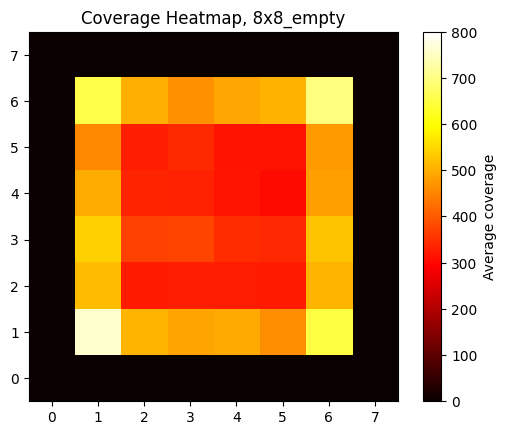

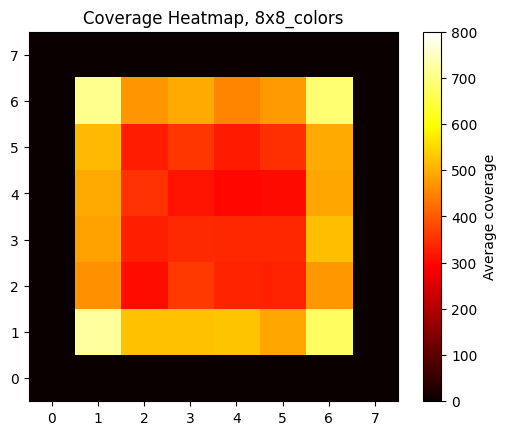

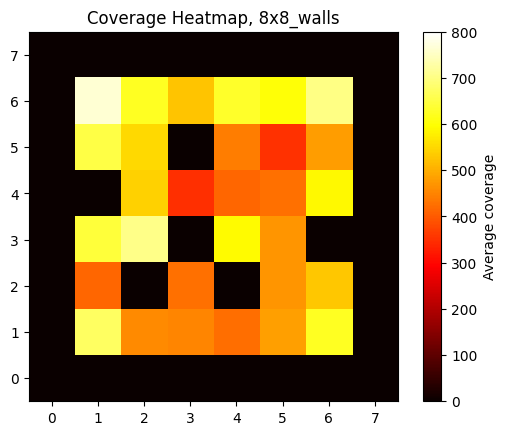

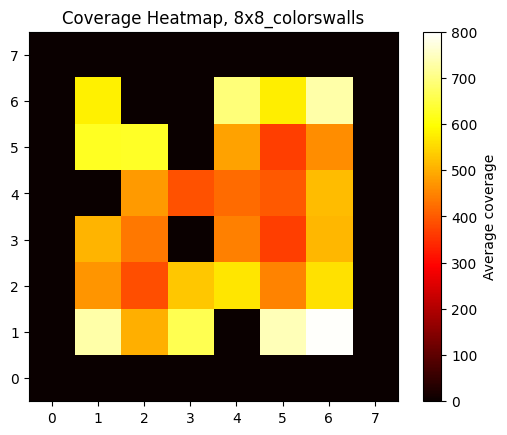

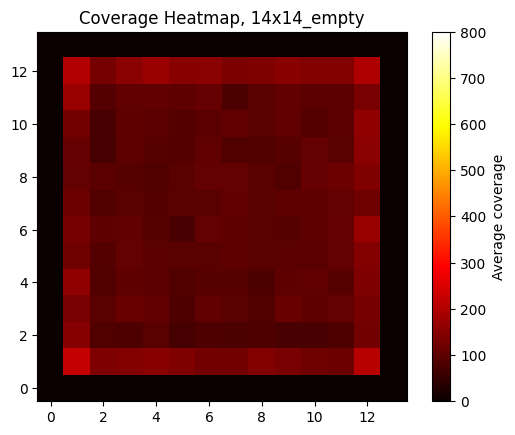

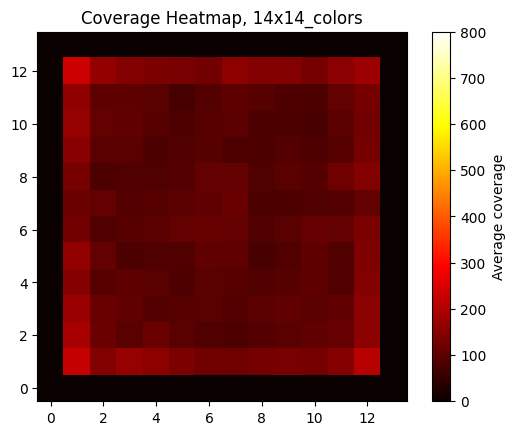

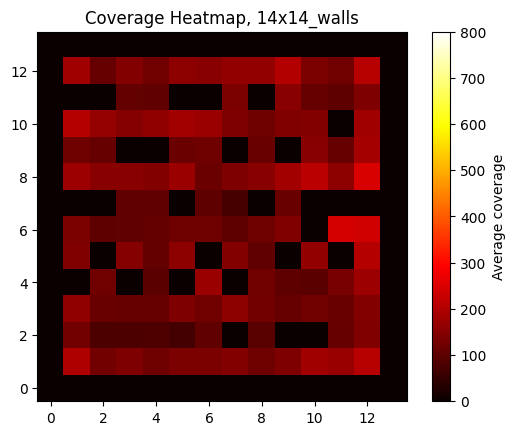

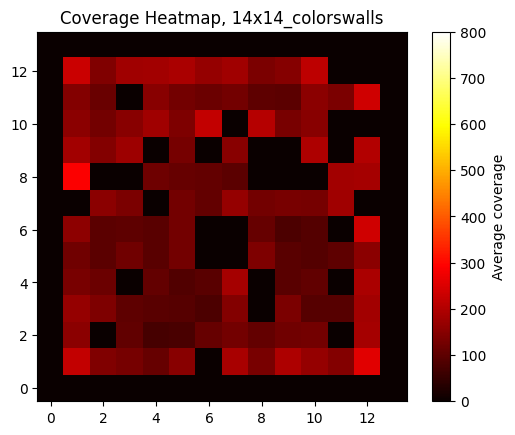

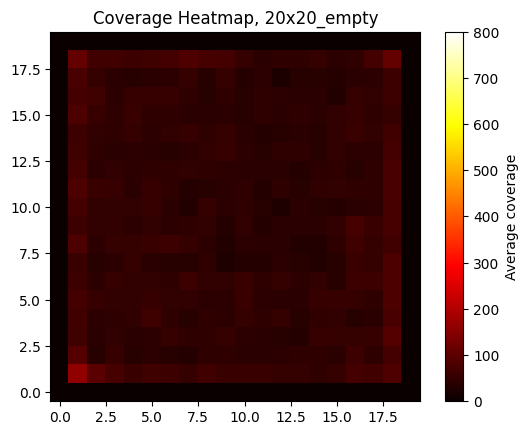

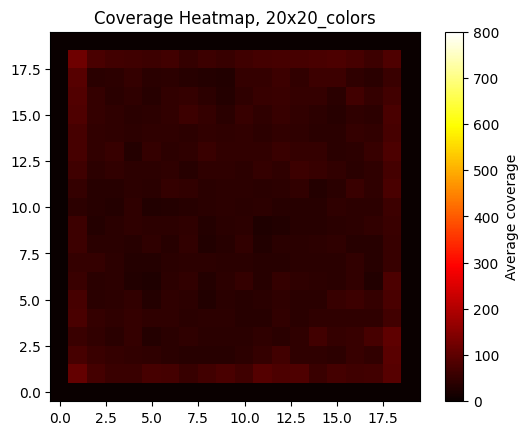

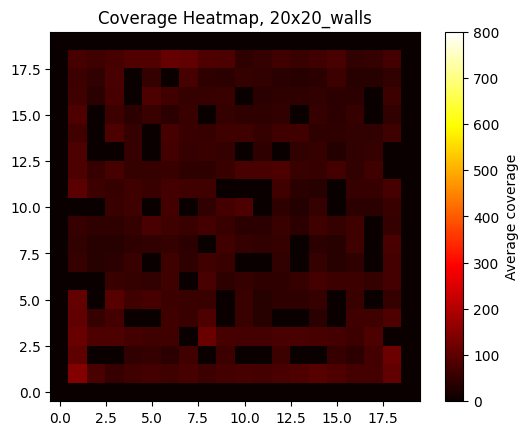

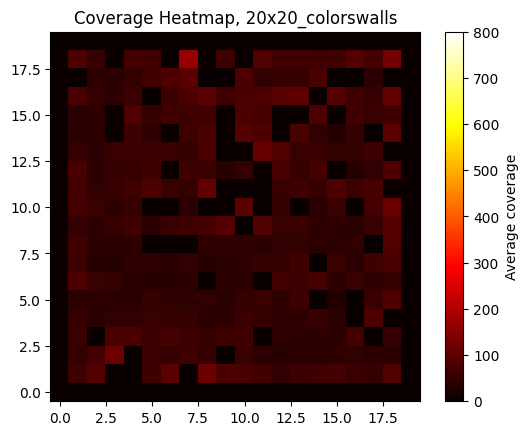

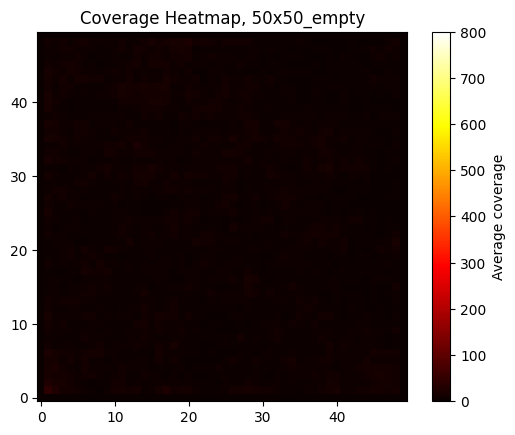

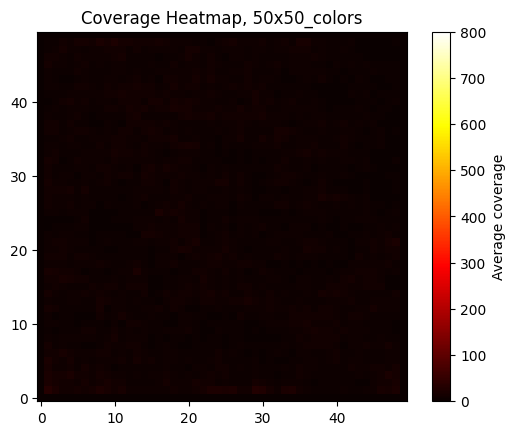

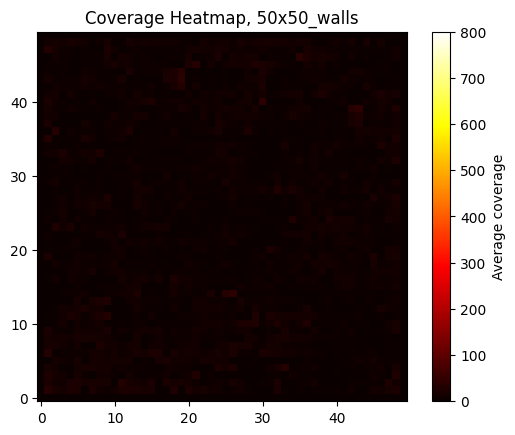

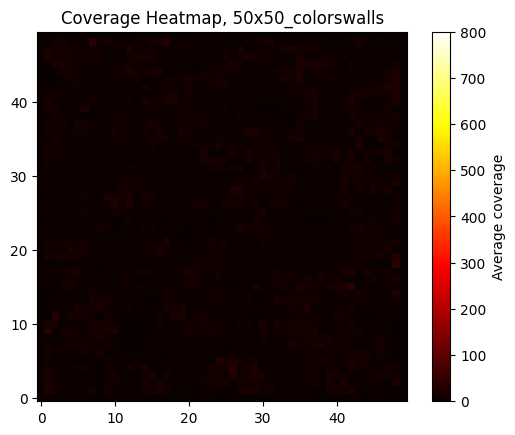

In [ ]:
for c in range(len(map_files)):
    map_width, map_height = dims[c]
    seeds_data = np.zeros((len(seeds), map_width, map_height))
    for s, seed in enumerate(seeds):
        coords = np.array(loaded_data[c][seed][1])
        if coords.size > 0:
            np.add.at(seeds_data[s], (coords[:,0], coords[:,1]), 1)
    avg_cover = np.mean(seeds_data, axis=0)

    plt.imshow(avg_cover, cmap='hot', interpolation='nearest',vmin=0,vmax=800)
    plt.imshow(avg_cover, cmap='hot', interpolation='nearest')
    plt.gca().invert_yaxis()
    plt.colorbar(label='Average coverage')
    plt.title(f"Coverage Heatmap, {map_labels[c]}")
    plt.show()

#### View env

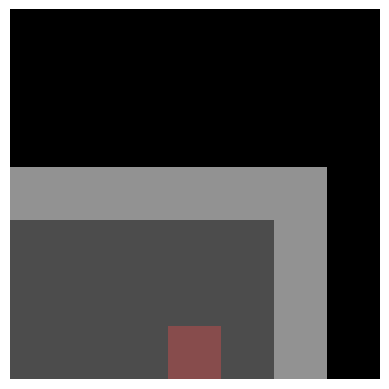

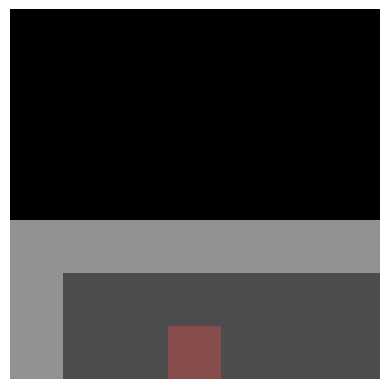

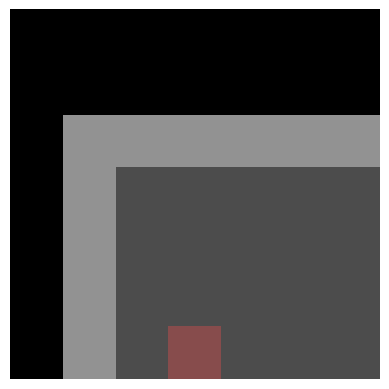

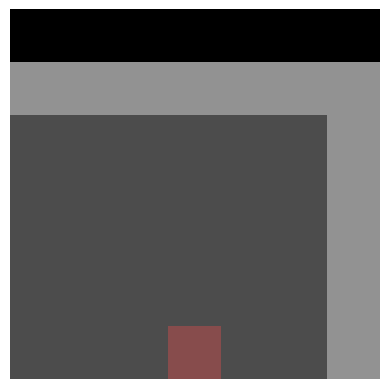

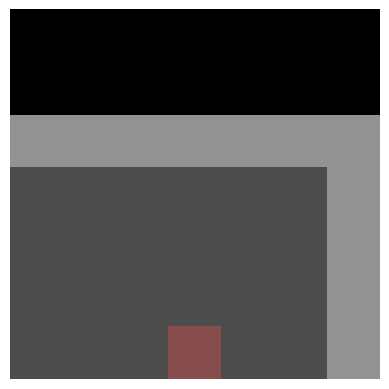

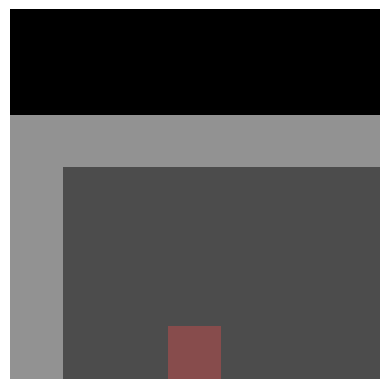

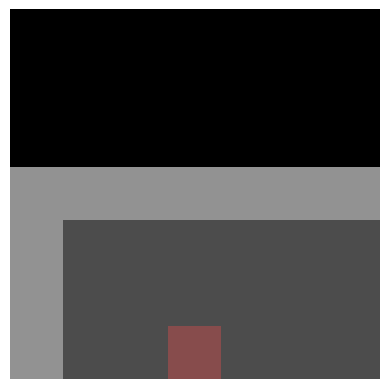

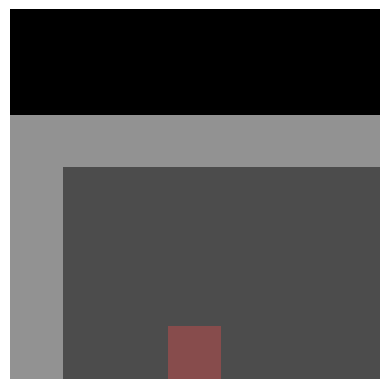

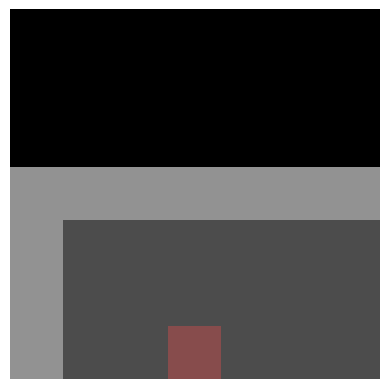

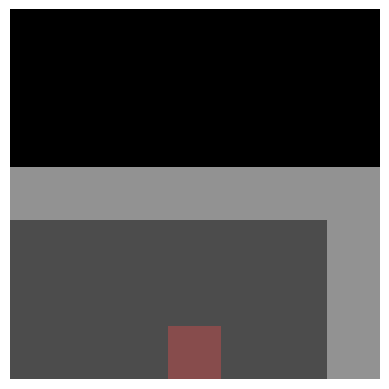

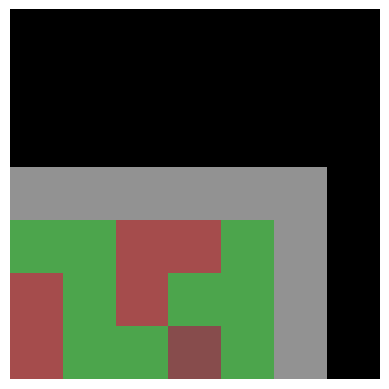

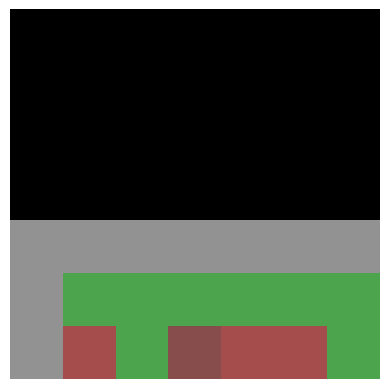

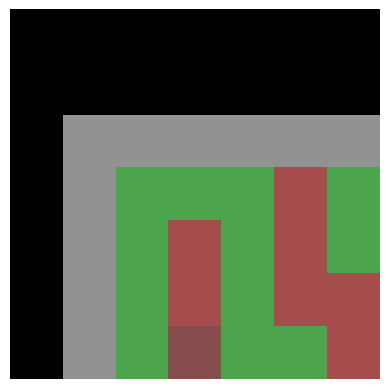

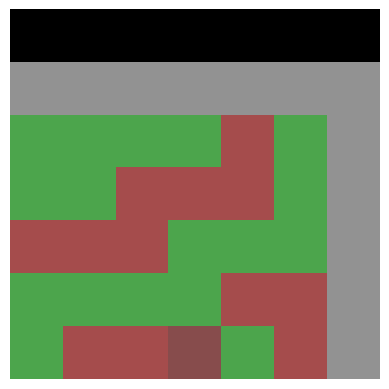

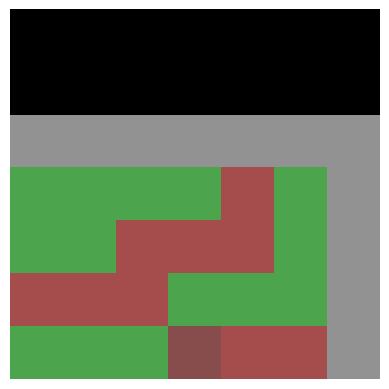

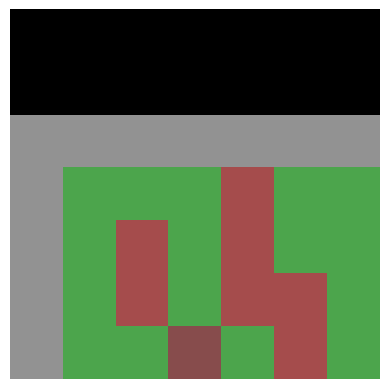

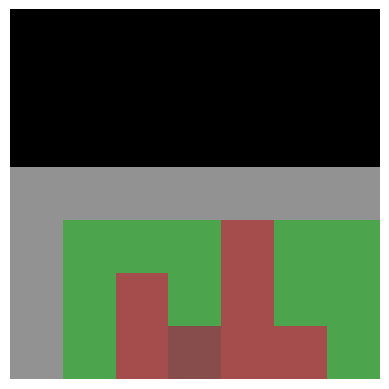

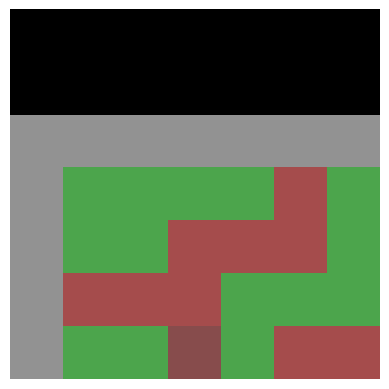

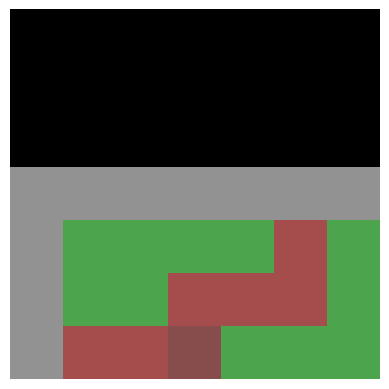

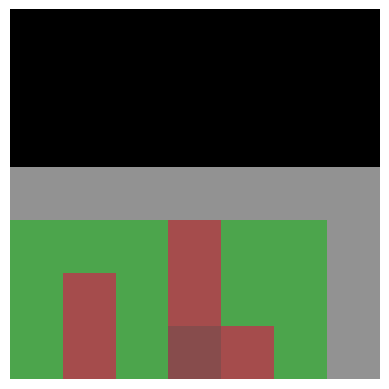

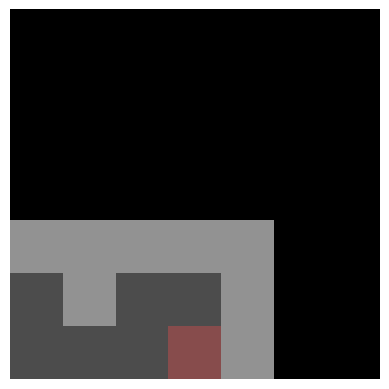

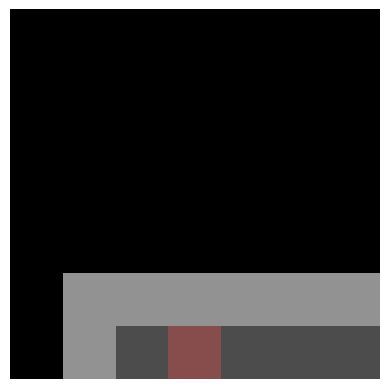

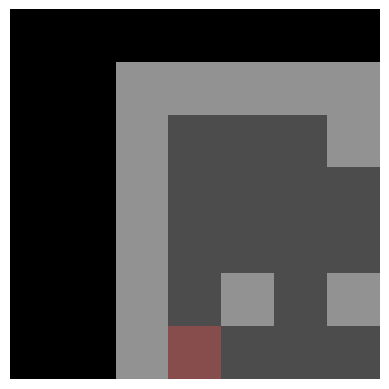

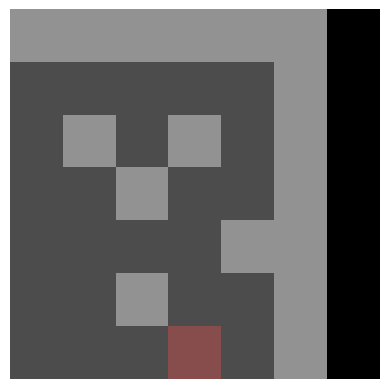

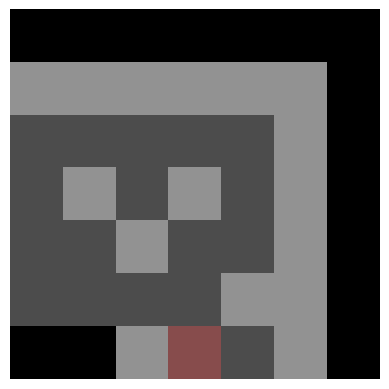

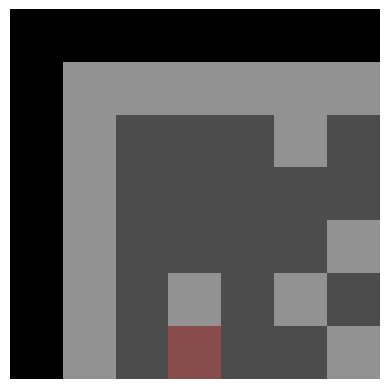

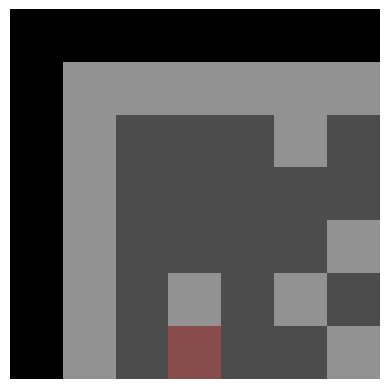

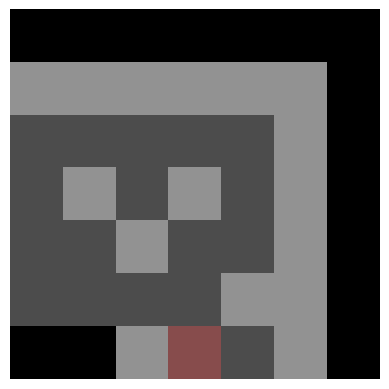

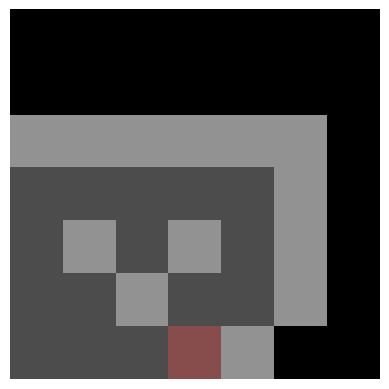

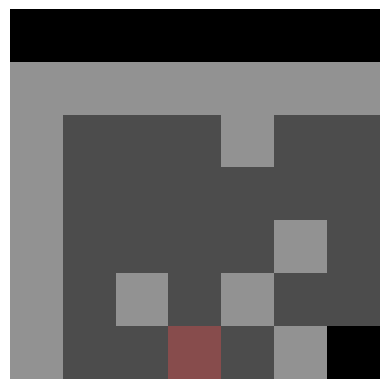

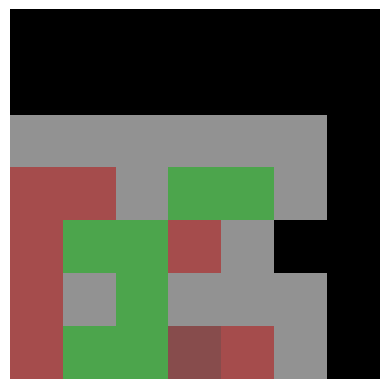

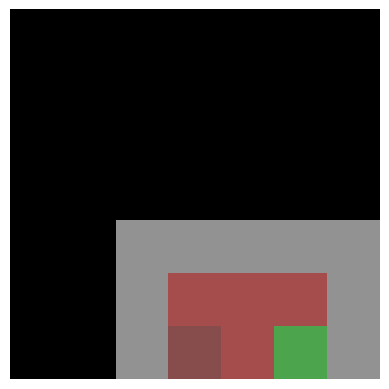

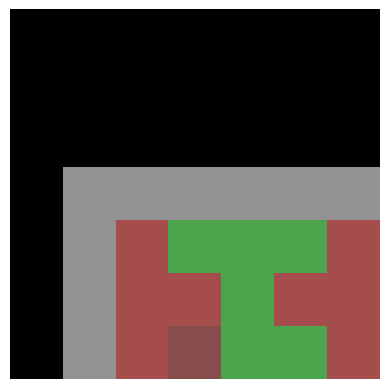

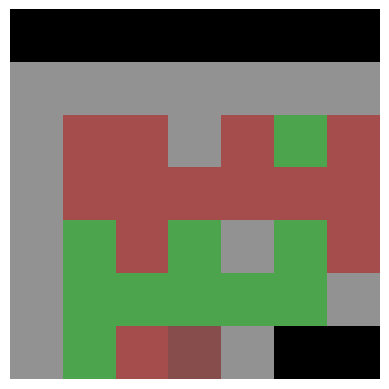

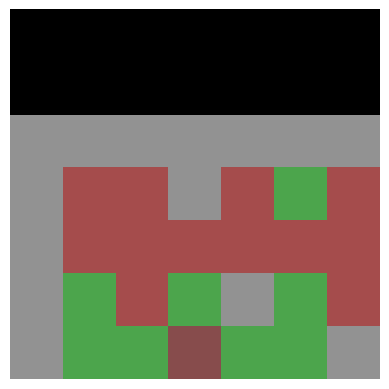

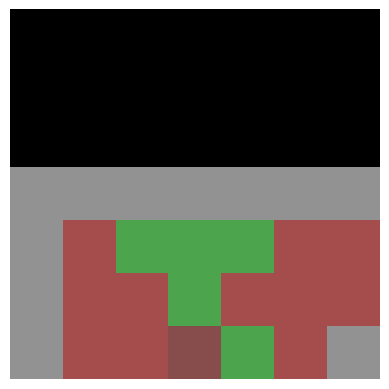

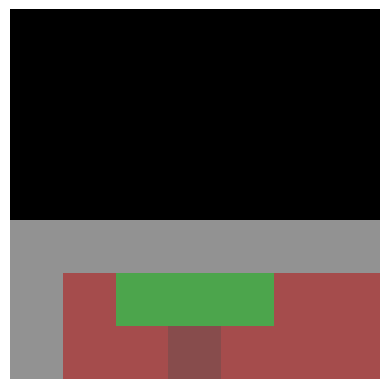

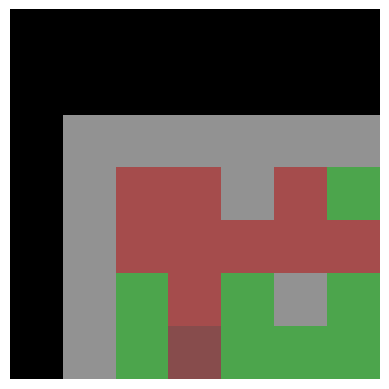

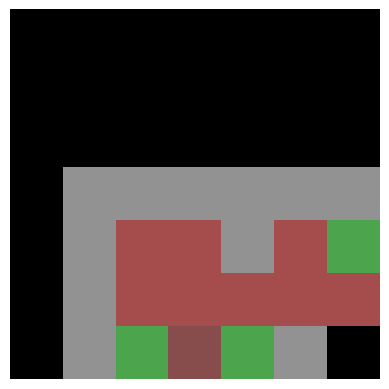

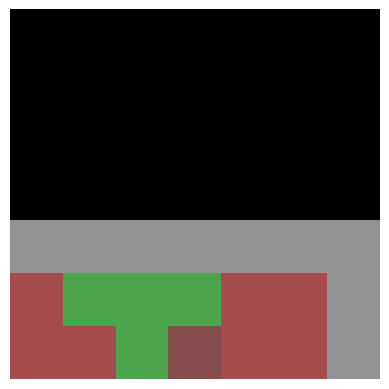

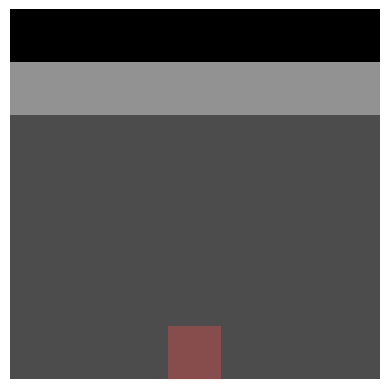

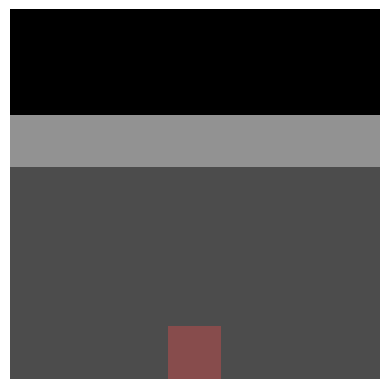

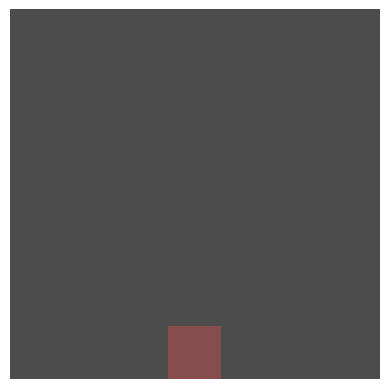

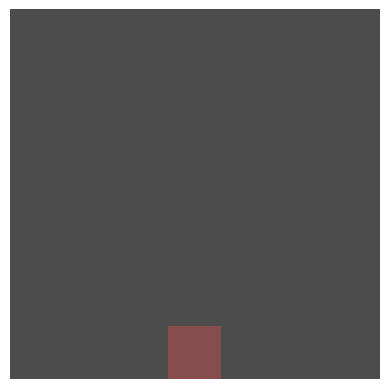

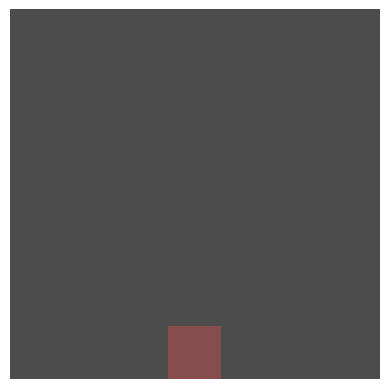

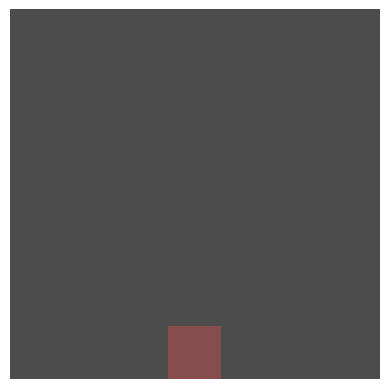

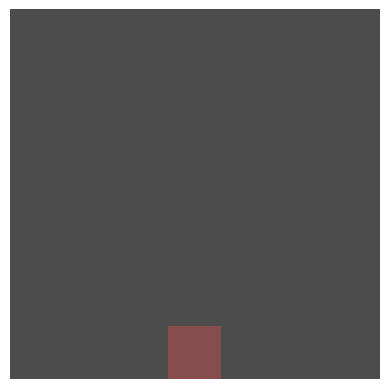

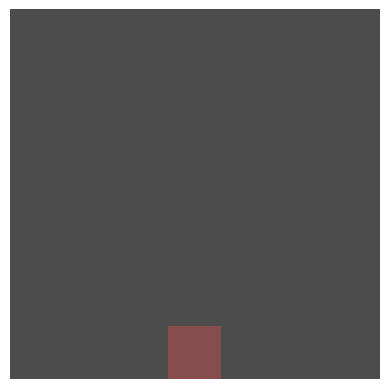

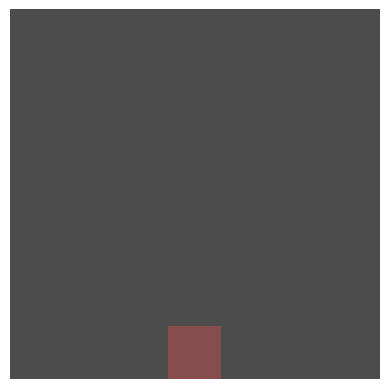

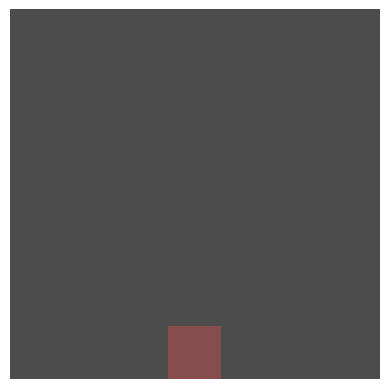

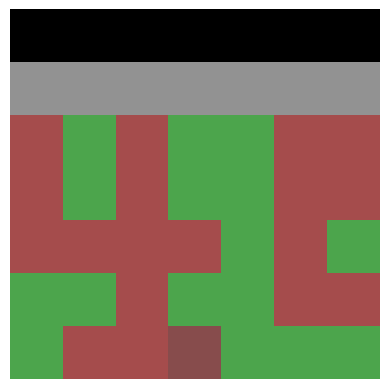

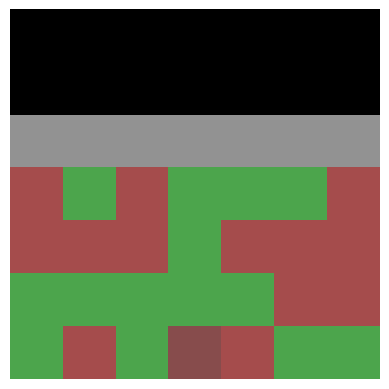

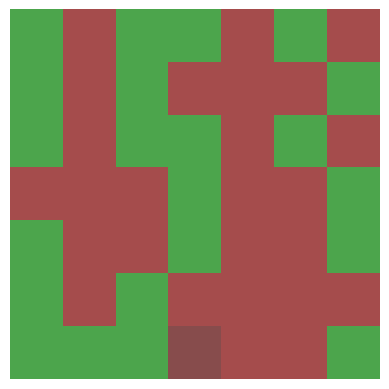

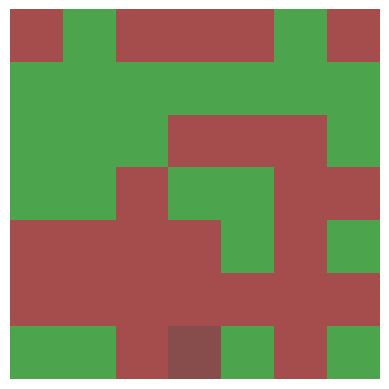

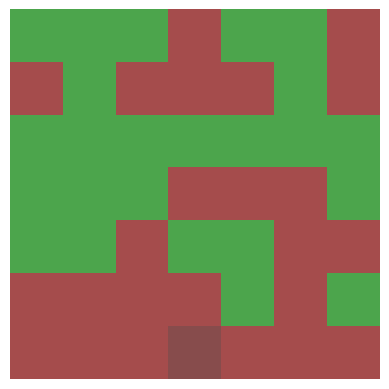

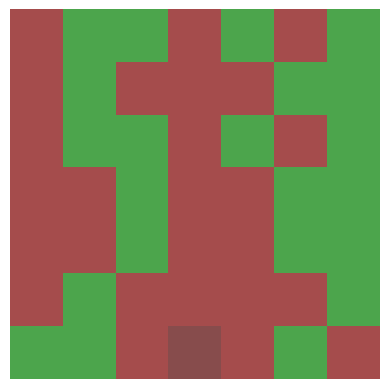

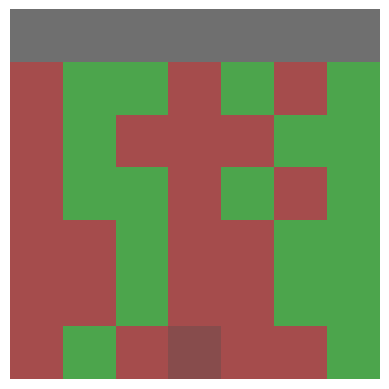

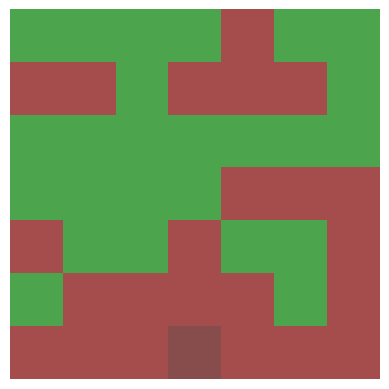

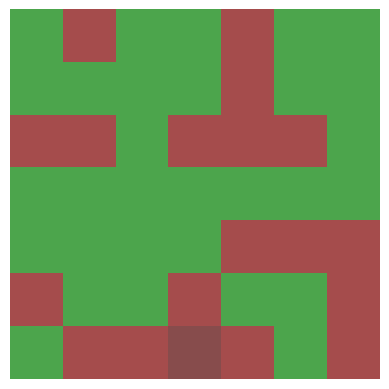

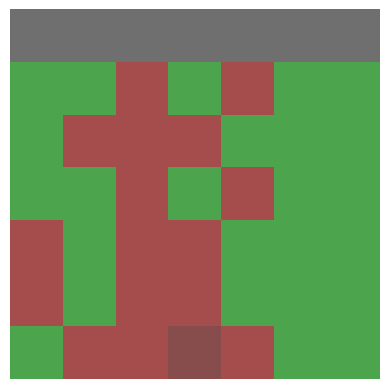

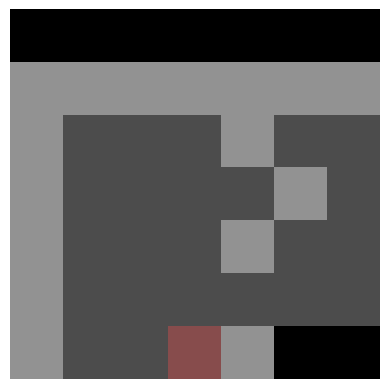

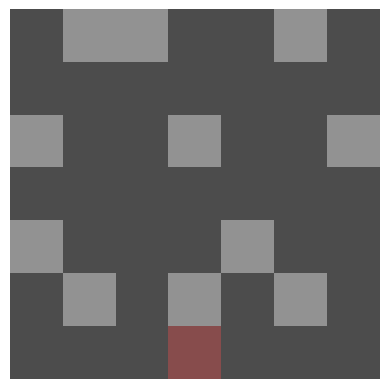

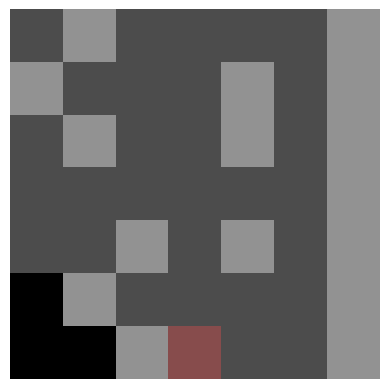

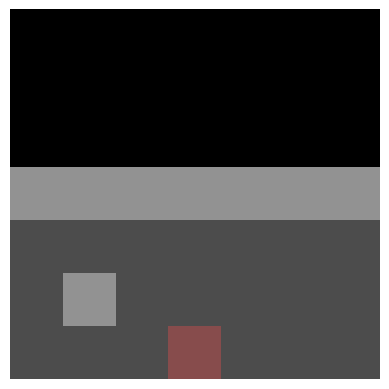

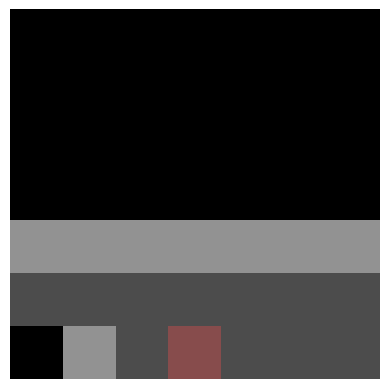

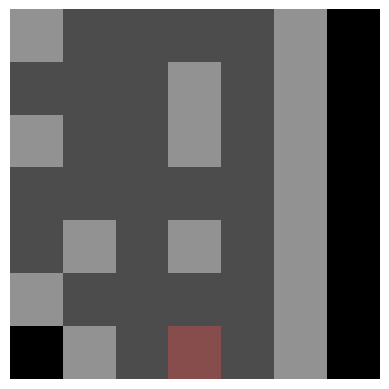

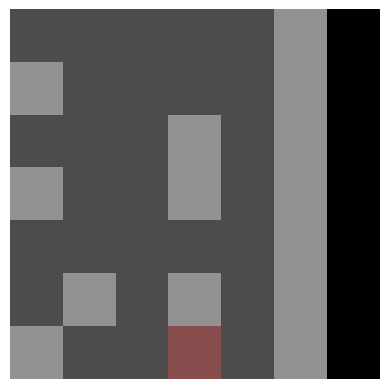

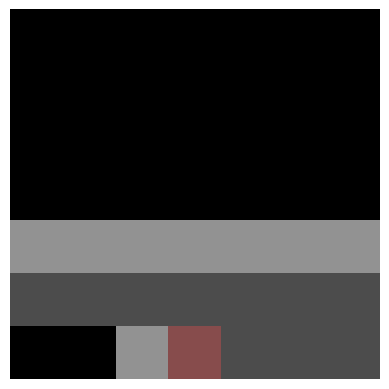

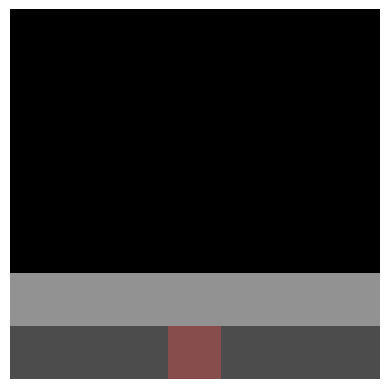

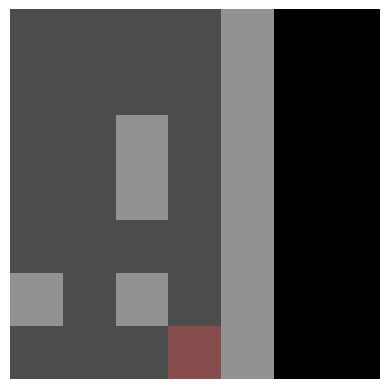

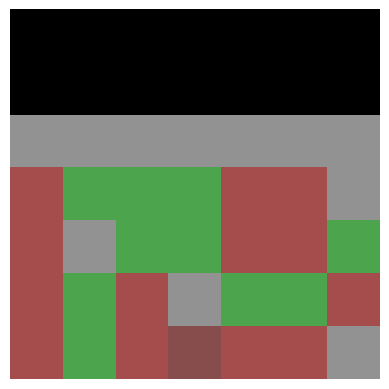

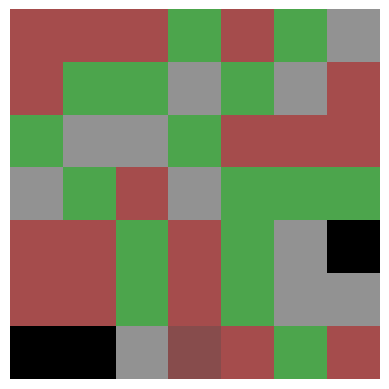

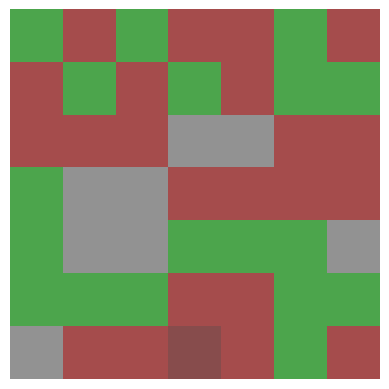

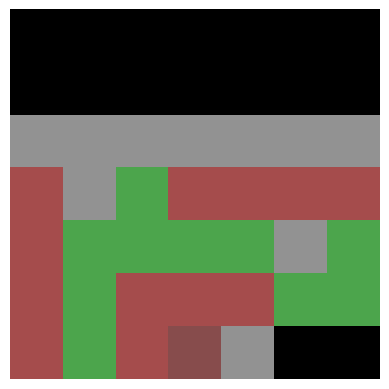

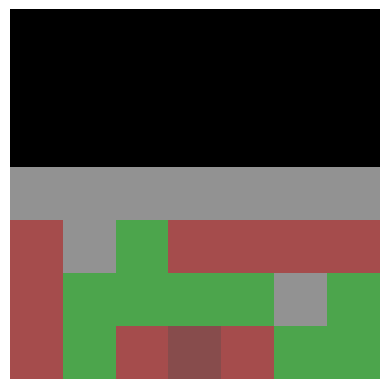

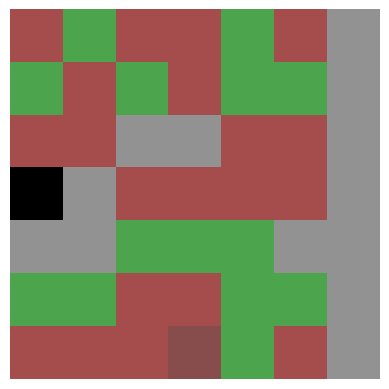

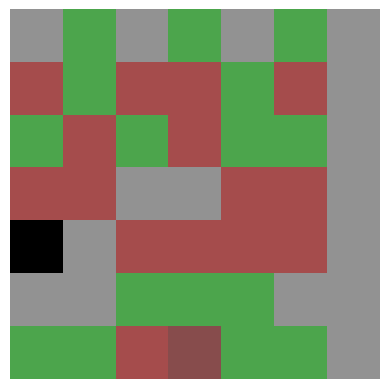

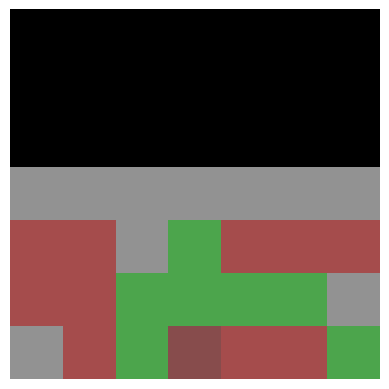

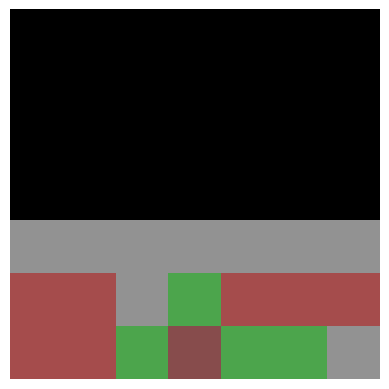

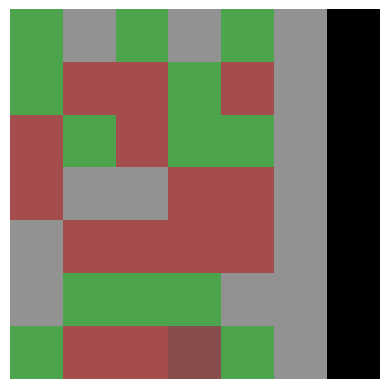

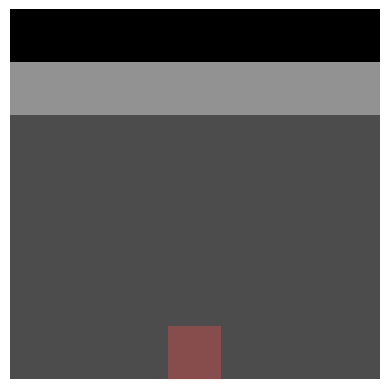

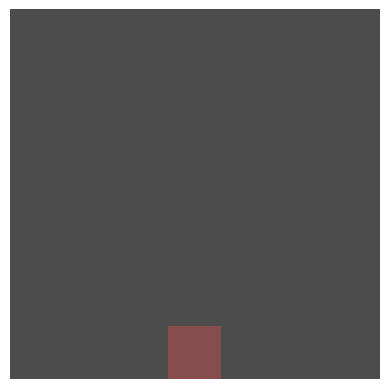

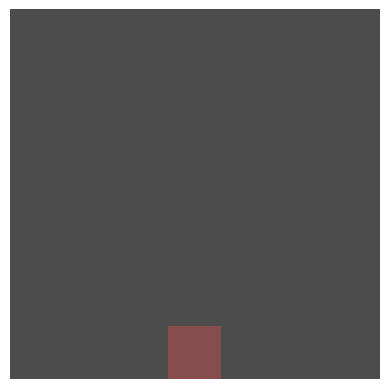

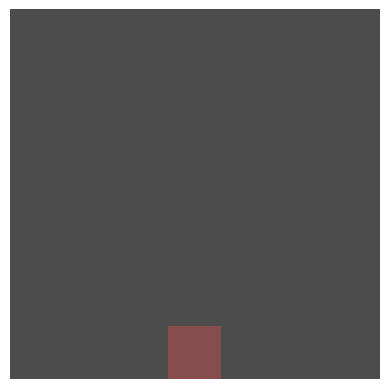

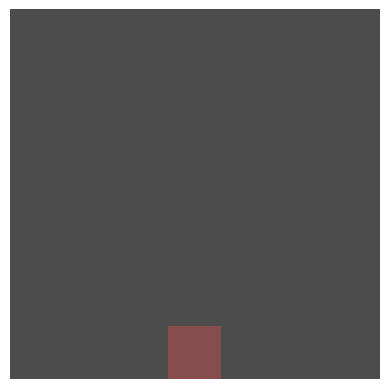

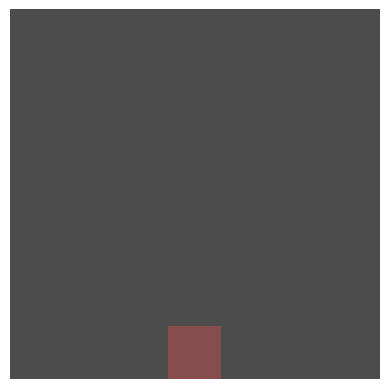

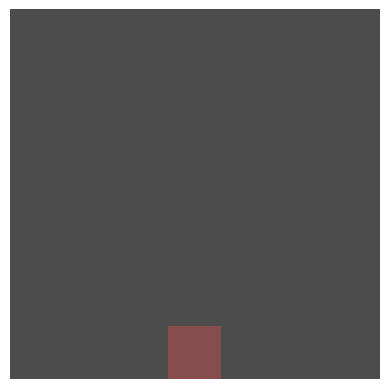

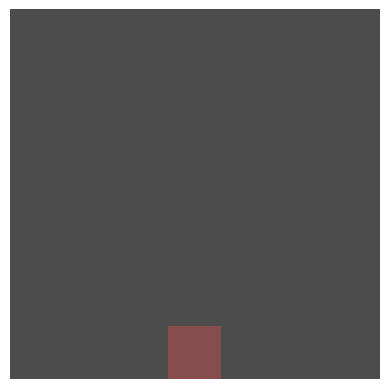

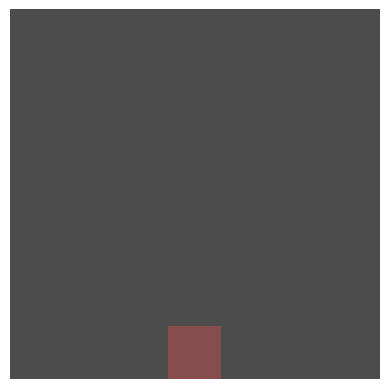

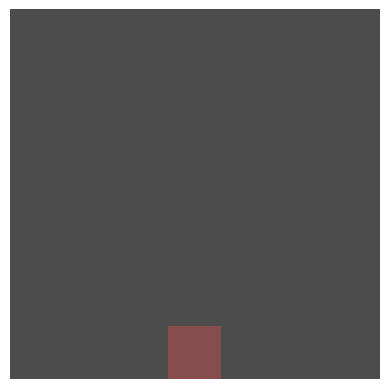

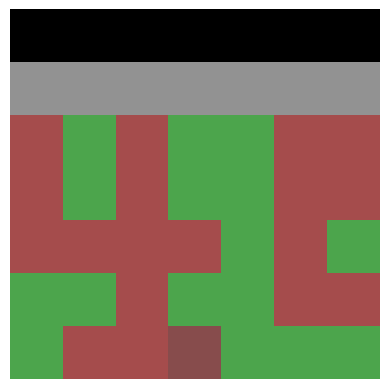

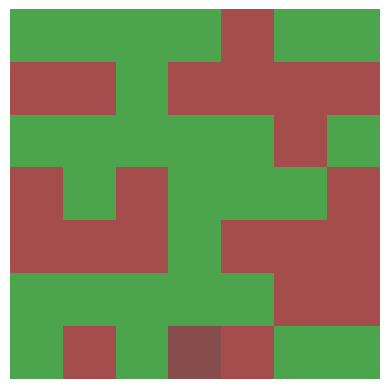

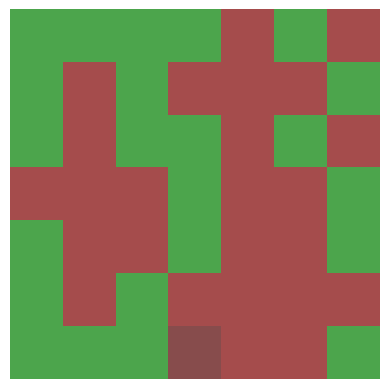

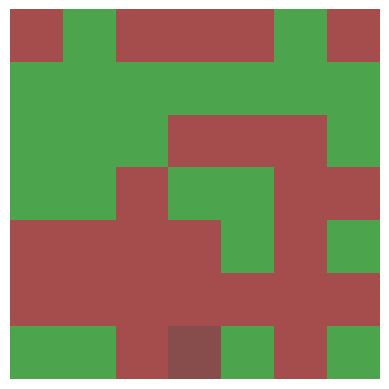

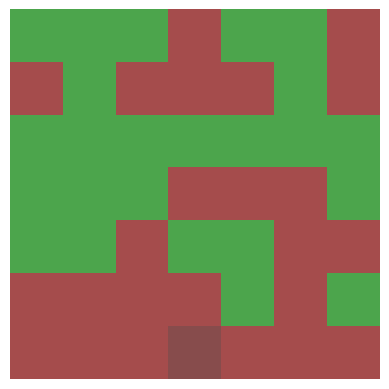

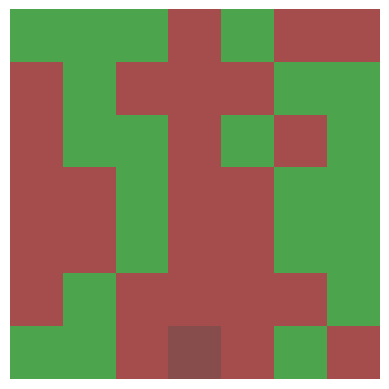

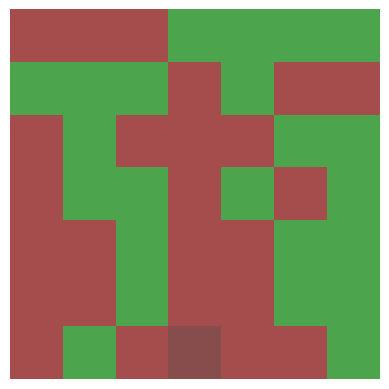

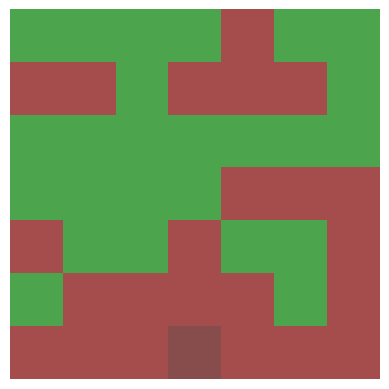

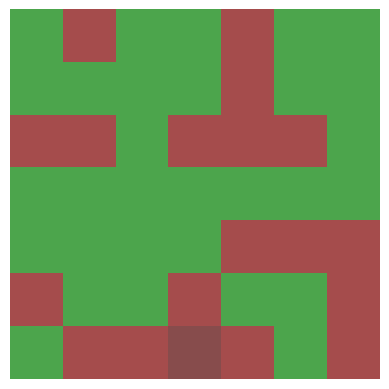

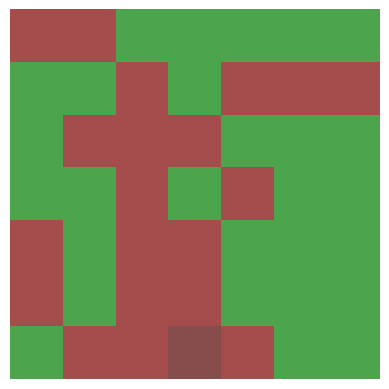

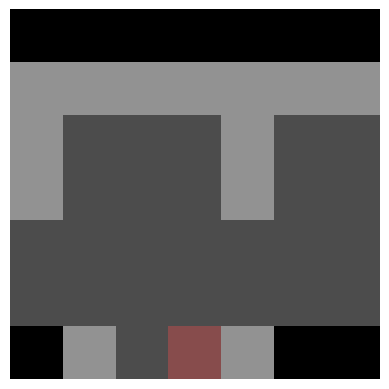

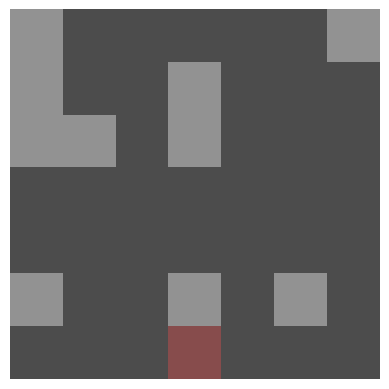

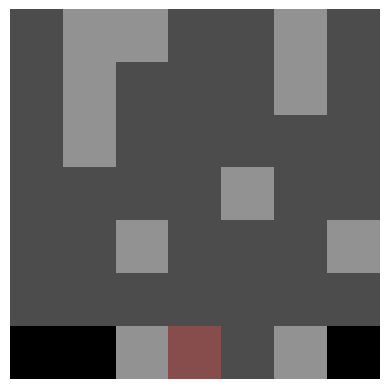

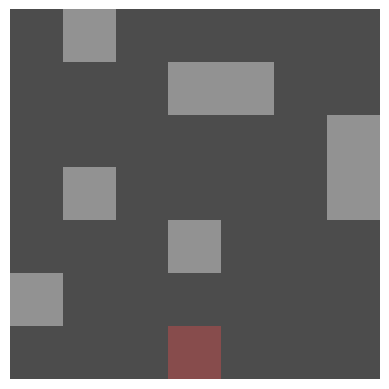

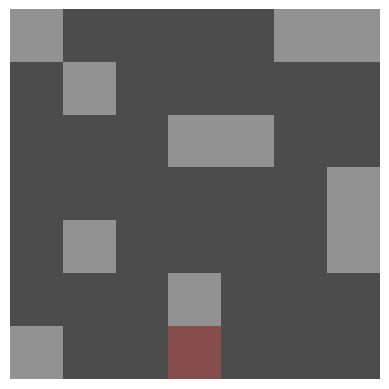

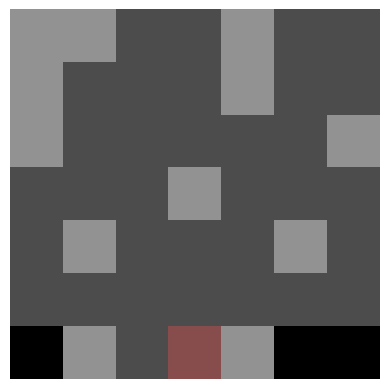

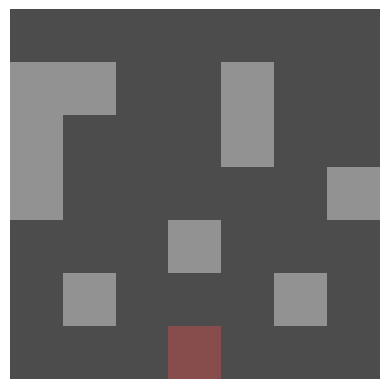

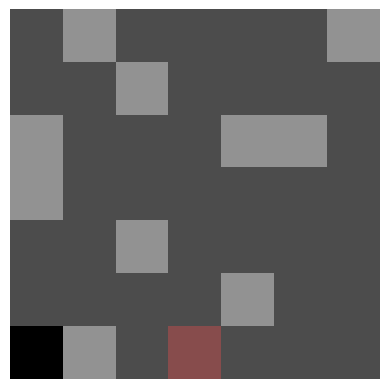

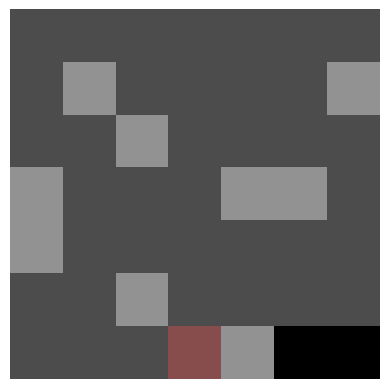

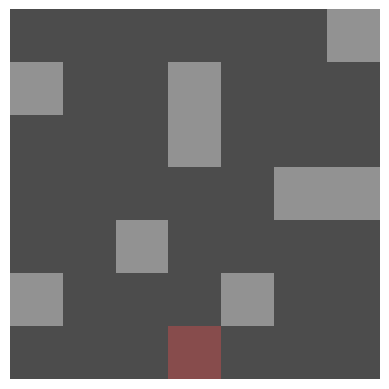

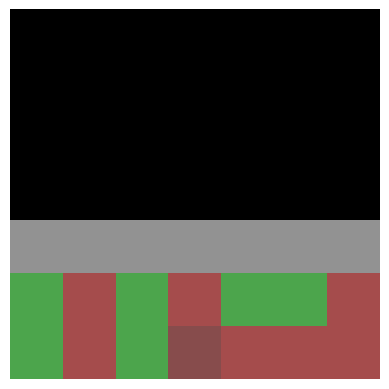

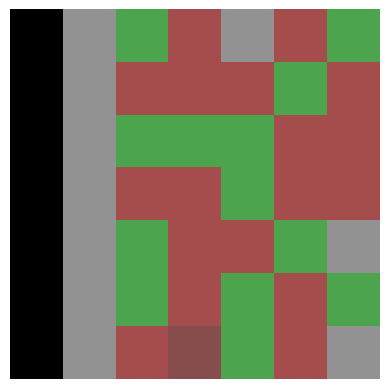

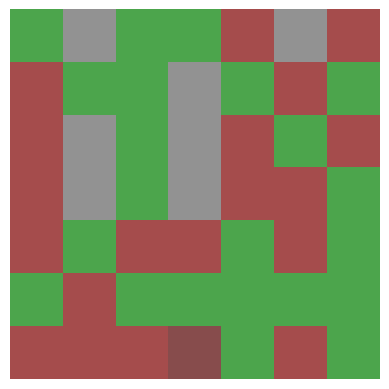

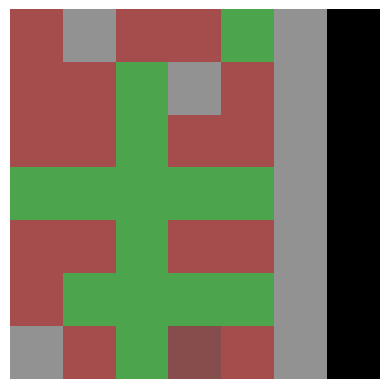

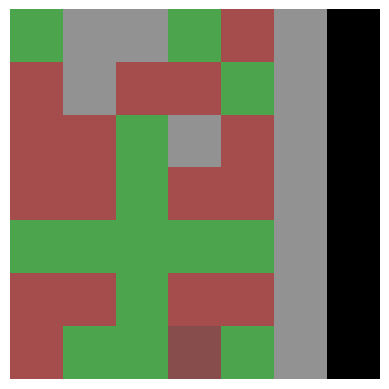

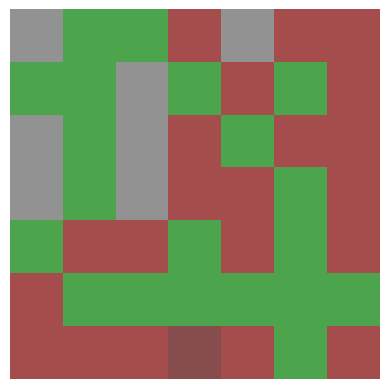

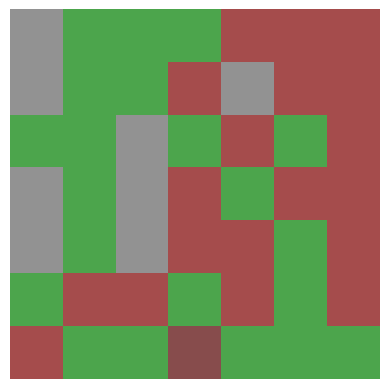

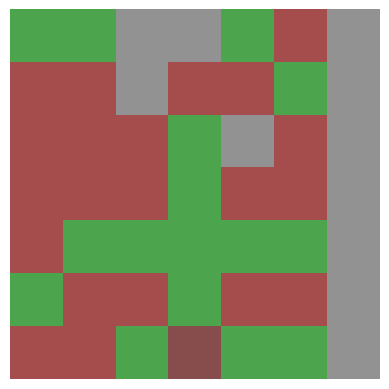

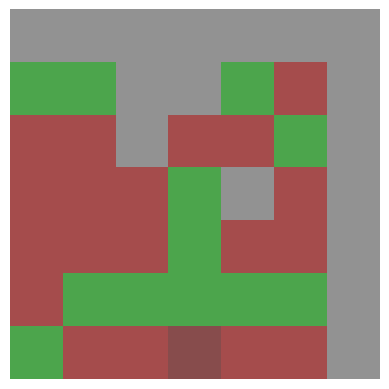

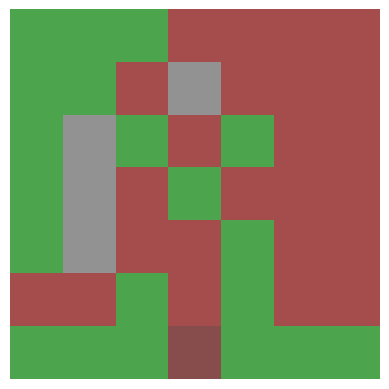

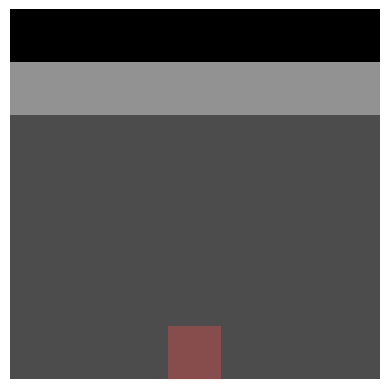

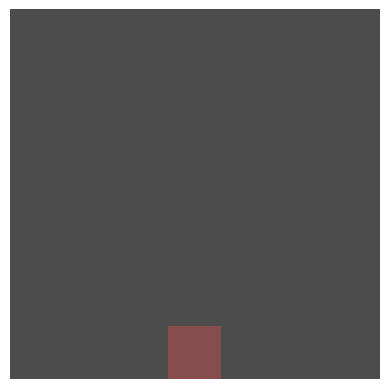

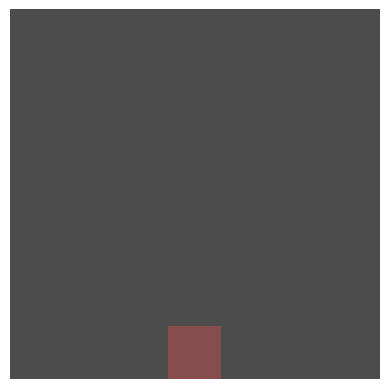

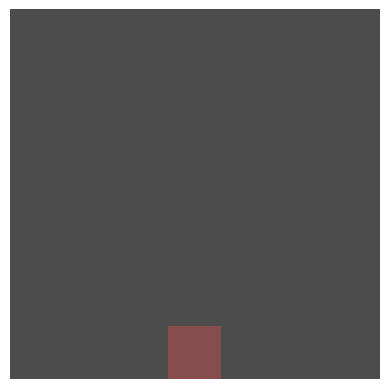

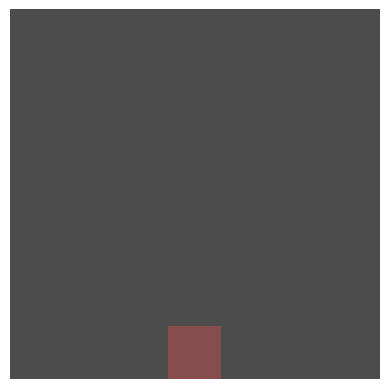

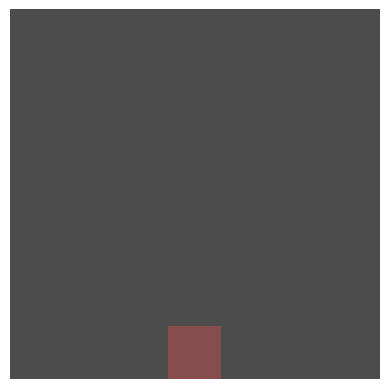

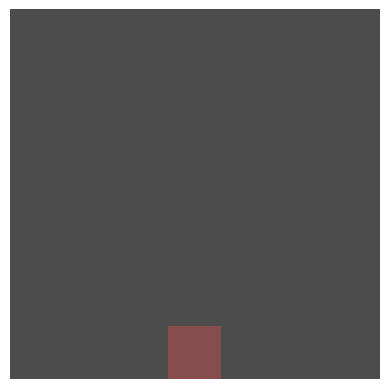

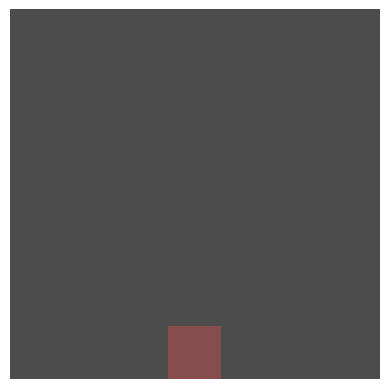

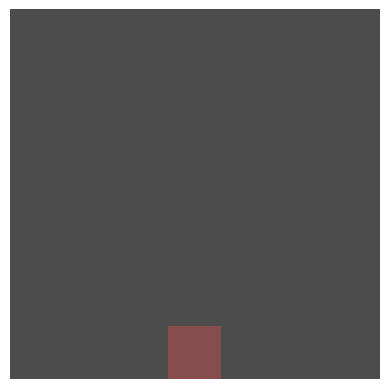

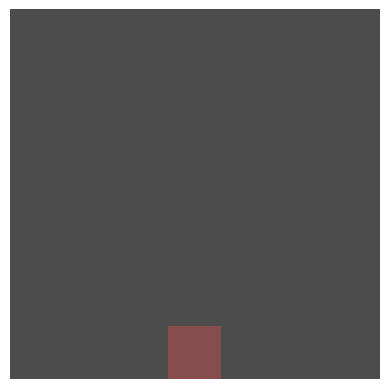

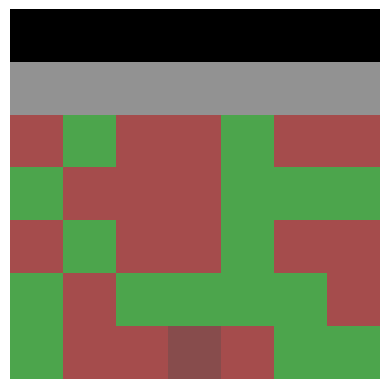

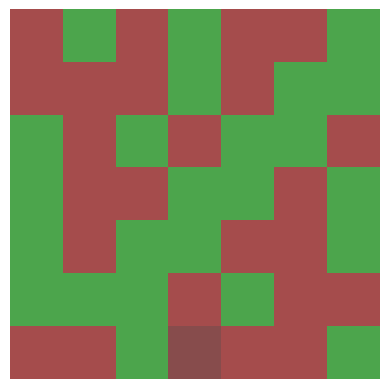

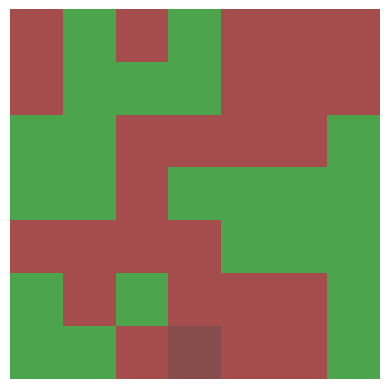

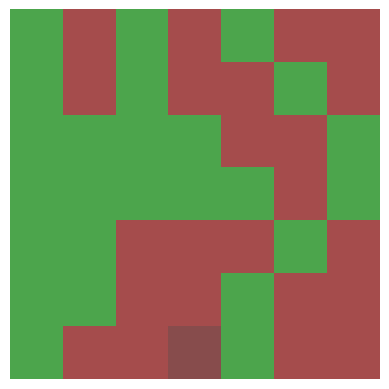

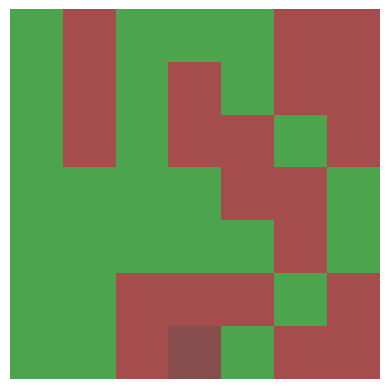

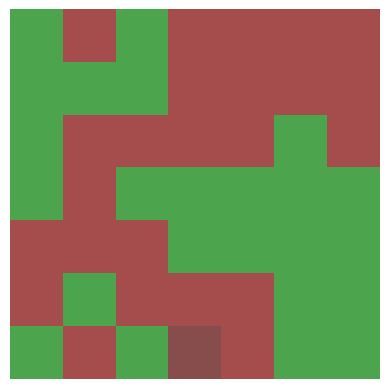

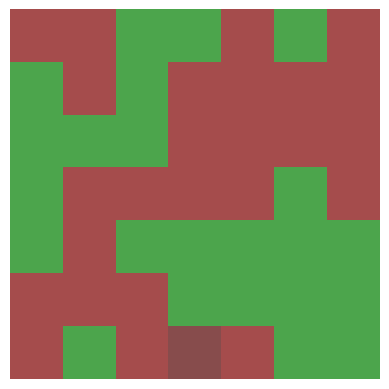

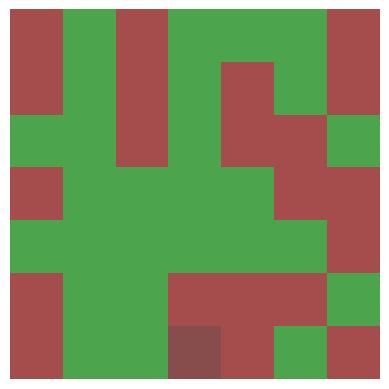

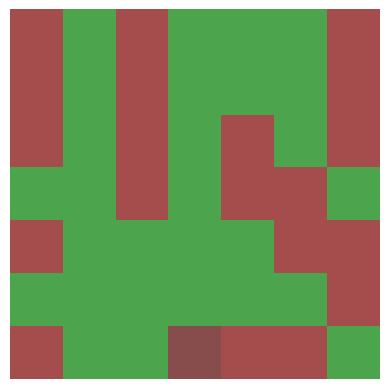

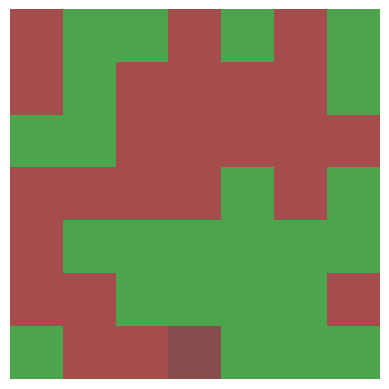

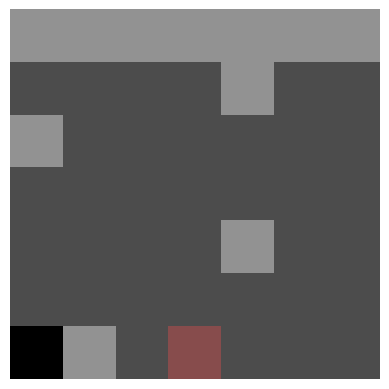

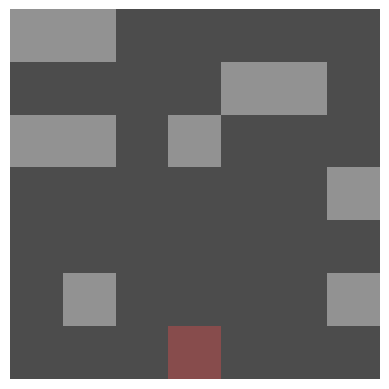

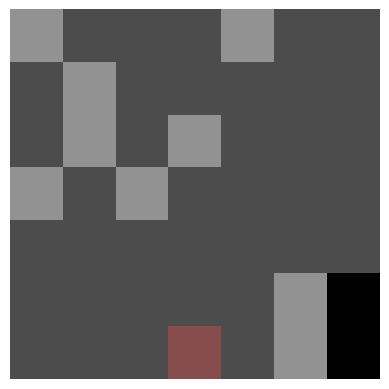

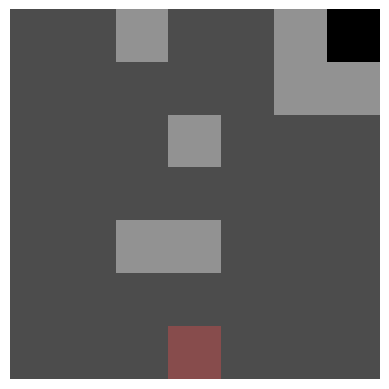

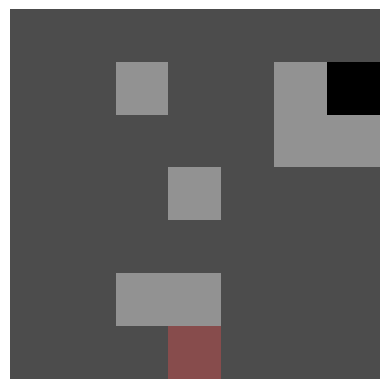

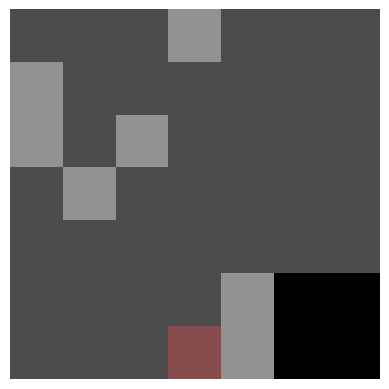

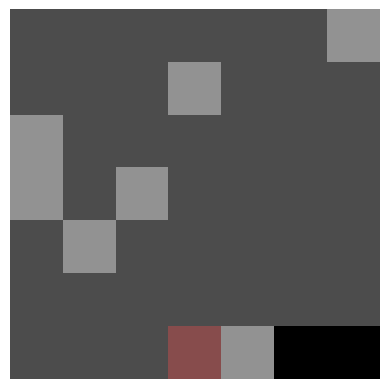

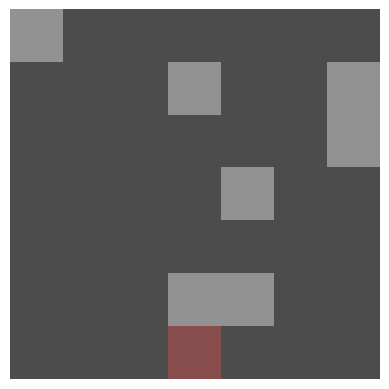

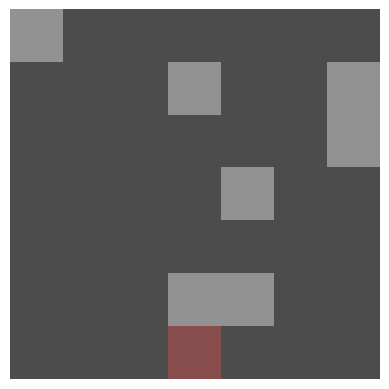

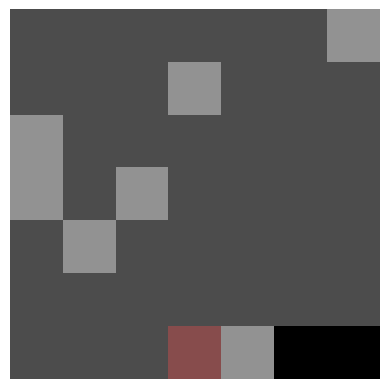

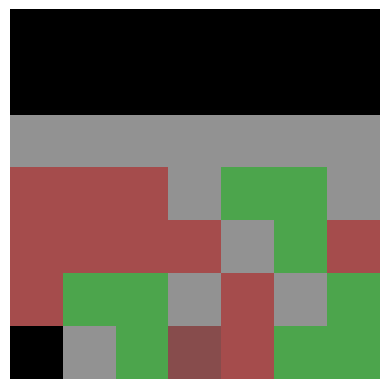

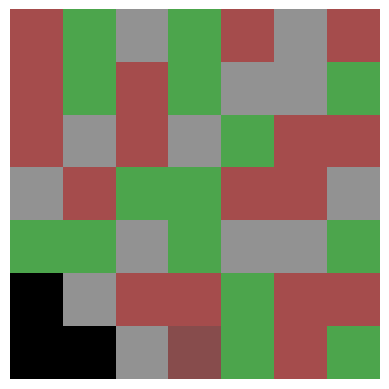

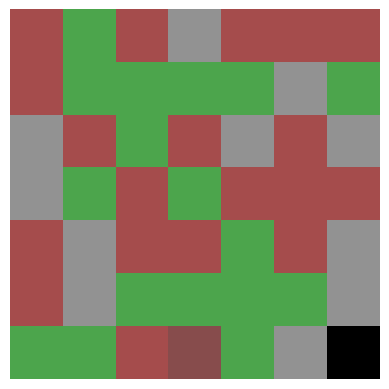

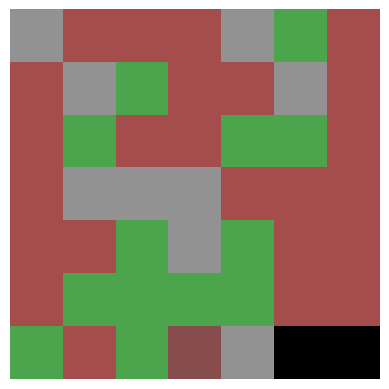

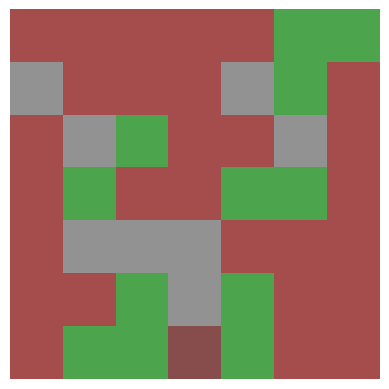

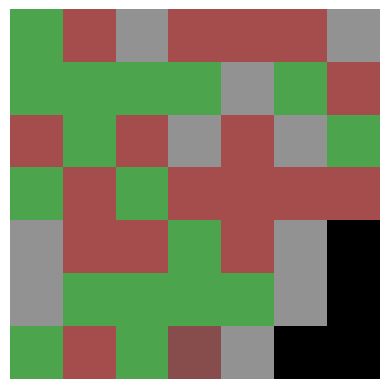

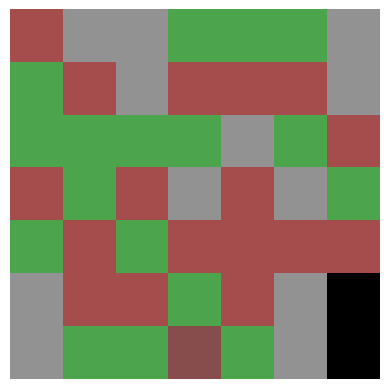

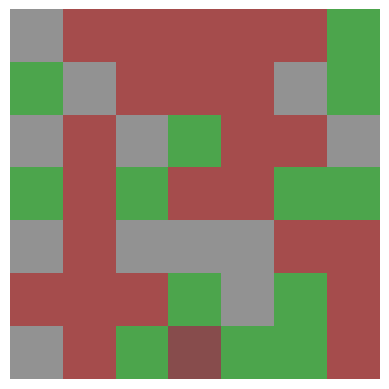

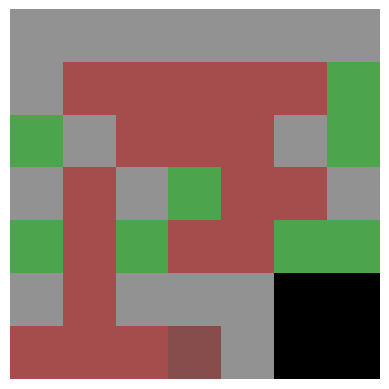

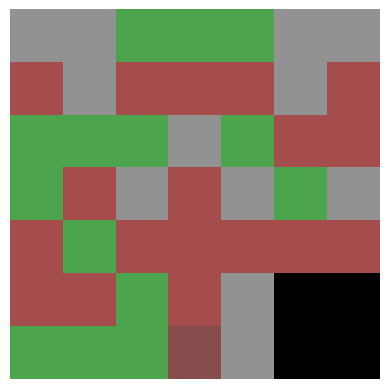

In [18]:
for c in range(len(map_labels)):
    ar = np.array(loaded_data[c][77243][0])[:,:-1]
    img = ar.reshape(-1,7, 7, 3).astype(np.uint8)

    for i in range(150,160):
        plt.imshow(img[i], interpolation='nearest')
        plt.axis('off') # Hide pixel coordinates
        plt.show()